**Brief info**

This dataset contains 1985 rows and 28 columns. The age range is between 1 to 18 years. Mostly they're from Europe, Asia and Meadle East. The number of males is nearly 3 times bigger than females. Surprisingly the overall male-to-female ratio is 9 to 1. In total 54% of candidates are ASD-positive. There are any features that are checked within candidates. 

'Social_Responsiveness_Scale',
'Speech Delay/Language Disorder',
'Learning disorder', 'Genetic_Disorders', 'Depression',
'Global developmental delay/intellectual disability',
'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
'Anxiety_disorder', 'Jaundice','Family_mem_with_ASD'

There are few outliers but we have some null values.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
sns.set_style('darkgrid')
import warnings
def ignore_warn(*args, **kwargs):
    pass
warnings.warn = ignore_warn
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('data_csv.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **EDA**

In [3]:
import pandas as pd

# Use r'' to handle backslashes safely on Windows
# Make sure to double check the path where the '...' is
df = pd.read_csv(r'./data_csv.csv')

df.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


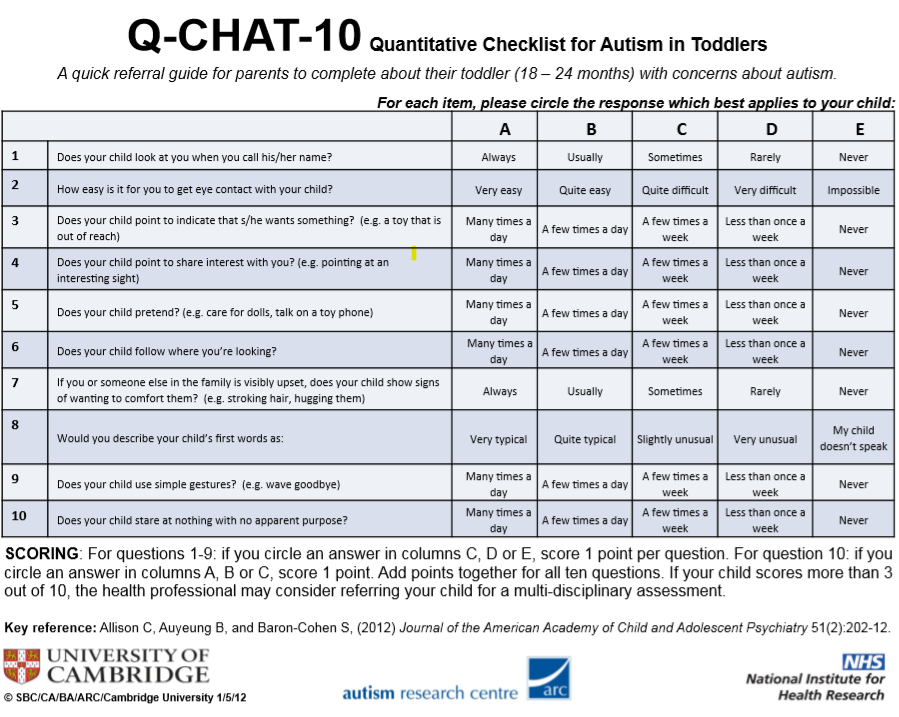

The Childhood Autism Rating Scale (CARS) is not a survey in the traditional sense. It is a standardized rating scale or assessment tool used by professionals to evaluate and assess the presence and severity of autism spectrum disorder (ASD) symptoms in children.

Instead of asking direct questions to complete a survey, the CARS involves direct observation of the child's behavior and interactions, as well as information provided by parents or caregivers. The person conducting the assessment would observe the child's social interactions, communication skills, and repetitive behaviors to determine their level of impairment in various domains associated with autism.

Based on these observations, the assessor scores each item on a four-point scale, ranging from "no abnormality" to "severely abnormal." The total scores are then calculated and interpreted to determine the severity of autism symptoms and assist in making a diagnosis.

So, while it involves gathering information and assessing specific behaviors, it is distinct from a general survey format.

In [4]:
df.shape

(1985, 28)

In [5]:
df.columns

Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 28 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   CASE_NO_PATIENT'S                                   1985 non-null   int64  
 1   A1                                                  1985 non-null   int64  
 2   A2                                                  1985 non-null   int64  
 3   A3                                                  1985 non-null   int64  
 4   A4                                                  1985 non-null   int64  
 5   A5                                                  1985 non-null   int64  
 6   A6                                                  1985 non-null   int64  
 7   A7                                                  1985 non-null   int64  
 8   A8                                                  1985 non-null   int64  
 9   A9      

**No null values**

In [7]:
# Option 1: Convert 'Yes' to 1 and 'No' to 0 automatically
df.replace({'Yes': 1, 'No': 0, 'f': 0, 'F': 0, 'm': 1, 'M': 1}, inplace=True)

# Select only numeric columns to avoid errors with other text columns (like Ethnicity)
numeric_df = df.select_dtypes(include=['number'])

# Now calculate skew
numeric_df.skew()

CASE_NO_PATIENT'S                0.000000
A1                               0.877465
A2                               1.229525
A3                               1.402302
A4                               1.025289
A5                               0.988515
A6                               0.841077
A7                               0.652209
A8                               1.194088
A9                               1.095432
A10_Autism_Spectrum_Quotient     0.216019
Social_Responsiveness_Scale      0.898488
Age_Years                       -0.008586
Qchat_10_Score                   0.263531
Childhood Autism Rating Scale    1.339290
dtype: float64

# **Checking unique values in Categorical feature**

In [8]:
# Get object type columns
object_cols = df.select_dtypes('O').columns

# Create new DataFrame
object_df = pd.DataFrame({
    'Objects': object_cols,
    'Unique values': [df[col].unique() for col in object_cols],
    'number of unique values':[df[col].nunique()for col in object_cols]
})

object_df

,Objects,Unique values,number of unique values
0,Speech Delay/Language Disorder,"[1, 0]",2
1,Learning disorder,"[1, 0]",2
2,Genetic_Disorders,"[1, 0]",2
3,Depression,"[1, 0, nan]",2
4,Global developmental delay/intellectual disabi...,"[1, 0]",2
5,Social/Behavioural Issues,"[1, nan, 0]",2
6,Anxiety_disorder,"[1, 0]",2
7,Sex,"[0, 1]",2
8,Ethnicity,"[middle eastern, White European, Middle Easter...",16
9,Jaundice,"[1, 0]",2


As you can see, for columns "Depression" and "Social/Behavioral issues there are some null values. Although from info() function we had no null values. so we should impute or drop rows with null values. also I need to check unique values of Ethnicity and who compeleted the test so there's no false dictation or something.

In [9]:
for col in ['Who_completed_the_test','Ethnicity']:
    print("-------------------------------")
    print(f'Column name: {col}\n')
    print(f'Unique values:\n{df[col].unique()}\n\n')

-------------------------------
Column name: Who_completed_the_test

Unique values:
<StringArray>
[           'Family Member', 'Health Care Professional',
                     'Self',            'Family member',
                   'Others',           'School and NGO']
Length: 6, dtype: str


-------------------------------
Column name: Ethnicity

Unique values:
<StringArray>
['middle eastern', 'White European', 'Middle Eastern',       'Hispanic',
          'Black',          'Asian',    'South Asian',  'Native Indian',
         'Others',          'black',          'asian',         'Latino',
          'Mixed',    'south asian',          'mixed',       'PaciFica']
Length: 16, dtype: str




In [10]:
df['Who_completed_the_test'] = df['Who_completed_the_test'].replace(["Family Member"], 'Family member')
replacements = {
    'middle eastern': 'Middle Eastern',
    'mixed': 'Mixed',
    'asian': 'Asian',
    'black': 'Black',
    'south asian': 'South Asian'
}
df['Ethnicity'] = df['Ethnicity'].replace(replacements)

In [11]:
for col in ['Who_completed_the_test','Ethnicity']:
    print("-------------------------------")
    print(f'Column name: {col}\n')
    print(f'Unique values:\n{df[col].unique()}\n\n')

-------------------------------
Column name: Who_completed_the_test

Unique values:
<StringArray>
['Family member', 'Health Care Professional', 'Self', 'Others',
 'School and NGO']
Length: 5, dtype: str


-------------------------------
Column name: Ethnicity

Unique values:
<StringArray>
['Middle Eastern', 'White European',       'Hispanic',          'Black',
          'Asian',    'South Asian',  'Native Indian',         'Others',
         'Latino',          'Mixed',       'PaciFica']
Length: 11, dtype: str




In [12]:
pd.DataFrame(df.isnull().sum(), 
             columns=["Missing Values"]).style.bar(color = "#84A9AC")

,Missing Values
CASE_NO_PATIENT'S,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


In [13]:
column_names = ['Social_Responsiveness_Scale', 'Social/Behavioural Issues', 'Depression', 'Qchat_10_Score']

null_rows = {}
for col in column_names:
    null_rows[col] = df[df[col].isnull()].index

null_rows


{'Social_Responsiveness_Scale': Index([277, 585, 653, 701, 750, 847, 931, 982, 1033], dtype='int64'),
 'Social/Behavioural Issues': Index([463, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500], dtype='int64'),
 'Depression': RangeIndex(start=1055, stop=1056, step=1),
 'Qchat_10_Score': Index([1055, 1065, 1075, 1085, 1095, 1105, 1115, 1125, 1135, 1145, 1183, 1197,
        1211, 1225, 1239, 1262, 1276, 1299, 1313, 1336, 1350, 1373, 1387, 1410,
        1424, 1447, 1461, 1484, 1498, 1521, 1535, 1558, 1572, 1595, 1609, 1632,
        1646, 1669, 1683],
       dtype='int64')}

There are no match between the rows with null values, so dropping cannot be a good solution, I will use appropriate impution method for each column.

In [14]:
import pandas as pd
import numpy as np

# Assuming you have a DataFrame called 'data' with columns 'feature1' and 'dependent_variable'

# Step 1: Prepare your data
# Subset A - Rows with non-null values
subset_A = df.dropna(subset=['Qchat_10_Score'])

# Subset B - Rows with null values
subset_B = df[df['Qchat_10_Score'].isnull()]

# Step 2: Randomly impute missing values in Subset B
imputed_values = np.random.choice(subset_A['Qchat_10_Score'], size=len(subset_B), replace=True)
subset_B['Qchat_10_Score'] = imputed_values

# Step 3: Combine imputed values with original data
imputed_data = pd.concat([subset_A, subset_B])


In [15]:
from sklearn.impute import SimpleImputer

# replace '?' with NaN
imputed_data[['Depression', 'Social_Responsiveness_Scale', 'Social/Behavioural Issues']].replace('?', np.nan, inplace=True)

# Imputing null values with most_frequent strategy
imputer = SimpleImputer(strategy='most_frequent')
imputed_data[['Depression', 'Social_Responsiveness_Scale', 'Social/Behavioural Issues']] = imputer.fit_transform(df[['Depression', 'Social_Responsiveness_Scale', 'Social/Behavioural Issues']])



In [16]:
pd.DataFrame(imputed_data.isnull().sum(), 
             columns=["Missing Values"]).style.bar(color = "#84A9AC")

d:\New folder (2)\New folder\year 4 (S.E)...Senior\1st semester\GRAD\starting up (5)\.venv\Lib\site-packages\pandas\io\formats\style.py:4438: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


,Missing Values
CASE_NO_PATIENT'S,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


The nulls are imputed, in further analysis we can change the methods to get better accuracy in prediction. for now, we will use the imputed data for visualization.

# **Visualization**

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Histogram
fig1 = go.Figure(data=[go.Histogram(x=imputed_data['Sex'],
                                    marker_color='#84A9AC')])

fig1.update_layout(title='<b>Counts of Male and Female</b>',
                   title_x=0.5,
                   title_font=dict(size=20),
                   uniformtext_minsize=15)

ModuleNotFoundError: No module named 'plotly'

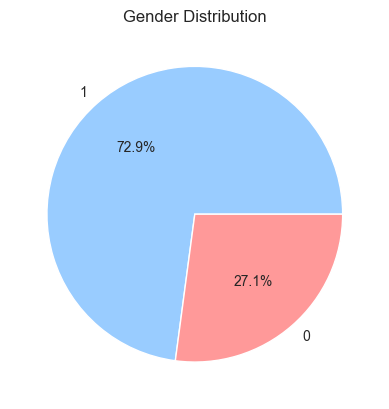

In [ ]:
import matplotlib.pyplot as plt

# Calculate the counts for each category
counts = imputed_data['Sex'].value_counts()

# Create a pie chart
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#99CCFF', '#FF9999'])
ax.set_title('Gender Distribution')

plt.show()


The number of boys is about 3 time bigger than girls.

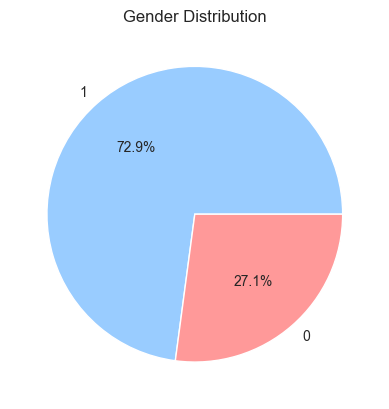

In [18]:
import matplotlib.pyplot as plt

# Calculate the counts for each category
counts = imputed_data['Sex'].value_counts()

# Create a pie chart
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#99CCFF', '#FF9999'])
ax.set_title('Gender Distribution')

plt.show()


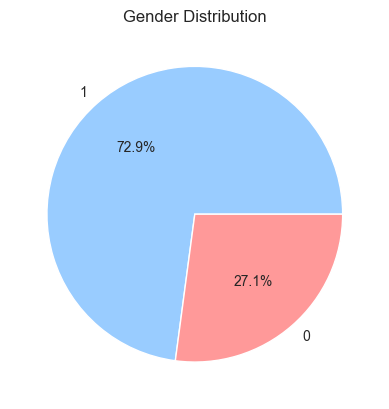

In [19]:
import matplotlib.pyplot as plt

# Calculate the counts for each category
counts = imputed_data['Sex'].value_counts()

# Create a pie chart
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#99CCFF', '#FF9999'])
ax.set_title('Gender Distribution')

plt.show()


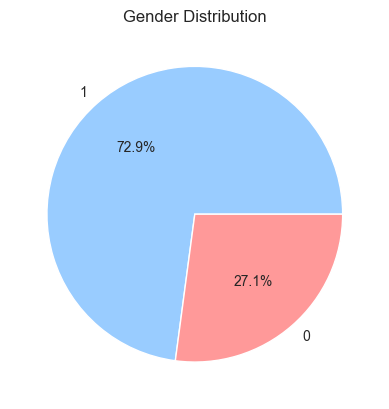

In [20]:
import matplotlib.pyplot as plt

# Calculate the counts for each category
counts = imputed_data['Sex'].value_counts()

# Create a pie chart
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#99CCFF', '#FF9999'])
ax.set_title('Gender Distribution')

plt.show()


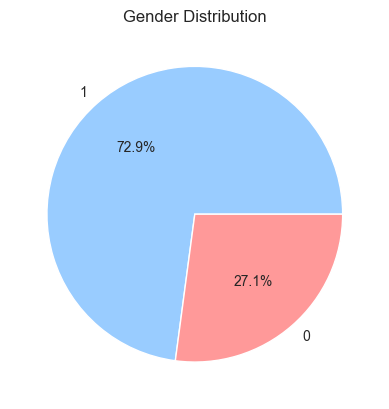

In [21]:
import matplotlib.pyplot as plt

# Calculate the counts for each category
counts = imputed_data['Sex'].value_counts()

# Create a pie chart
fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#99CCFF', '#FF9999'])
ax.set_title('Gender Distribution')

plt.show()


In [22]:
df.columns


Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='str')

In [23]:
df['ASD_traits'].value_counts()


ASD_traits
1    1074
0     911
Name: count, dtype: int64

In [ ]:
import plotly.express as px

fig = px.bar(imputed_data[imputed_data['ASD_traits'] == "Yes"].groupby('Sex').size().reset_index(name='counts'),
             x='Sex', y='counts')

fig.update_layout(title="<b>Gender Count of ASD Patients</b>", 
                  title_font_size=20, 
                  xaxis_title="Gender", 
                  yaxis_title="Counts", 
                  width=900)


fig.show()

ModuleNotFoundError: No module named 'plotly'

: 

As you see, the number of boys who are diagnosed is much higher.

# **Count of ASD patients based on Ethnicity**

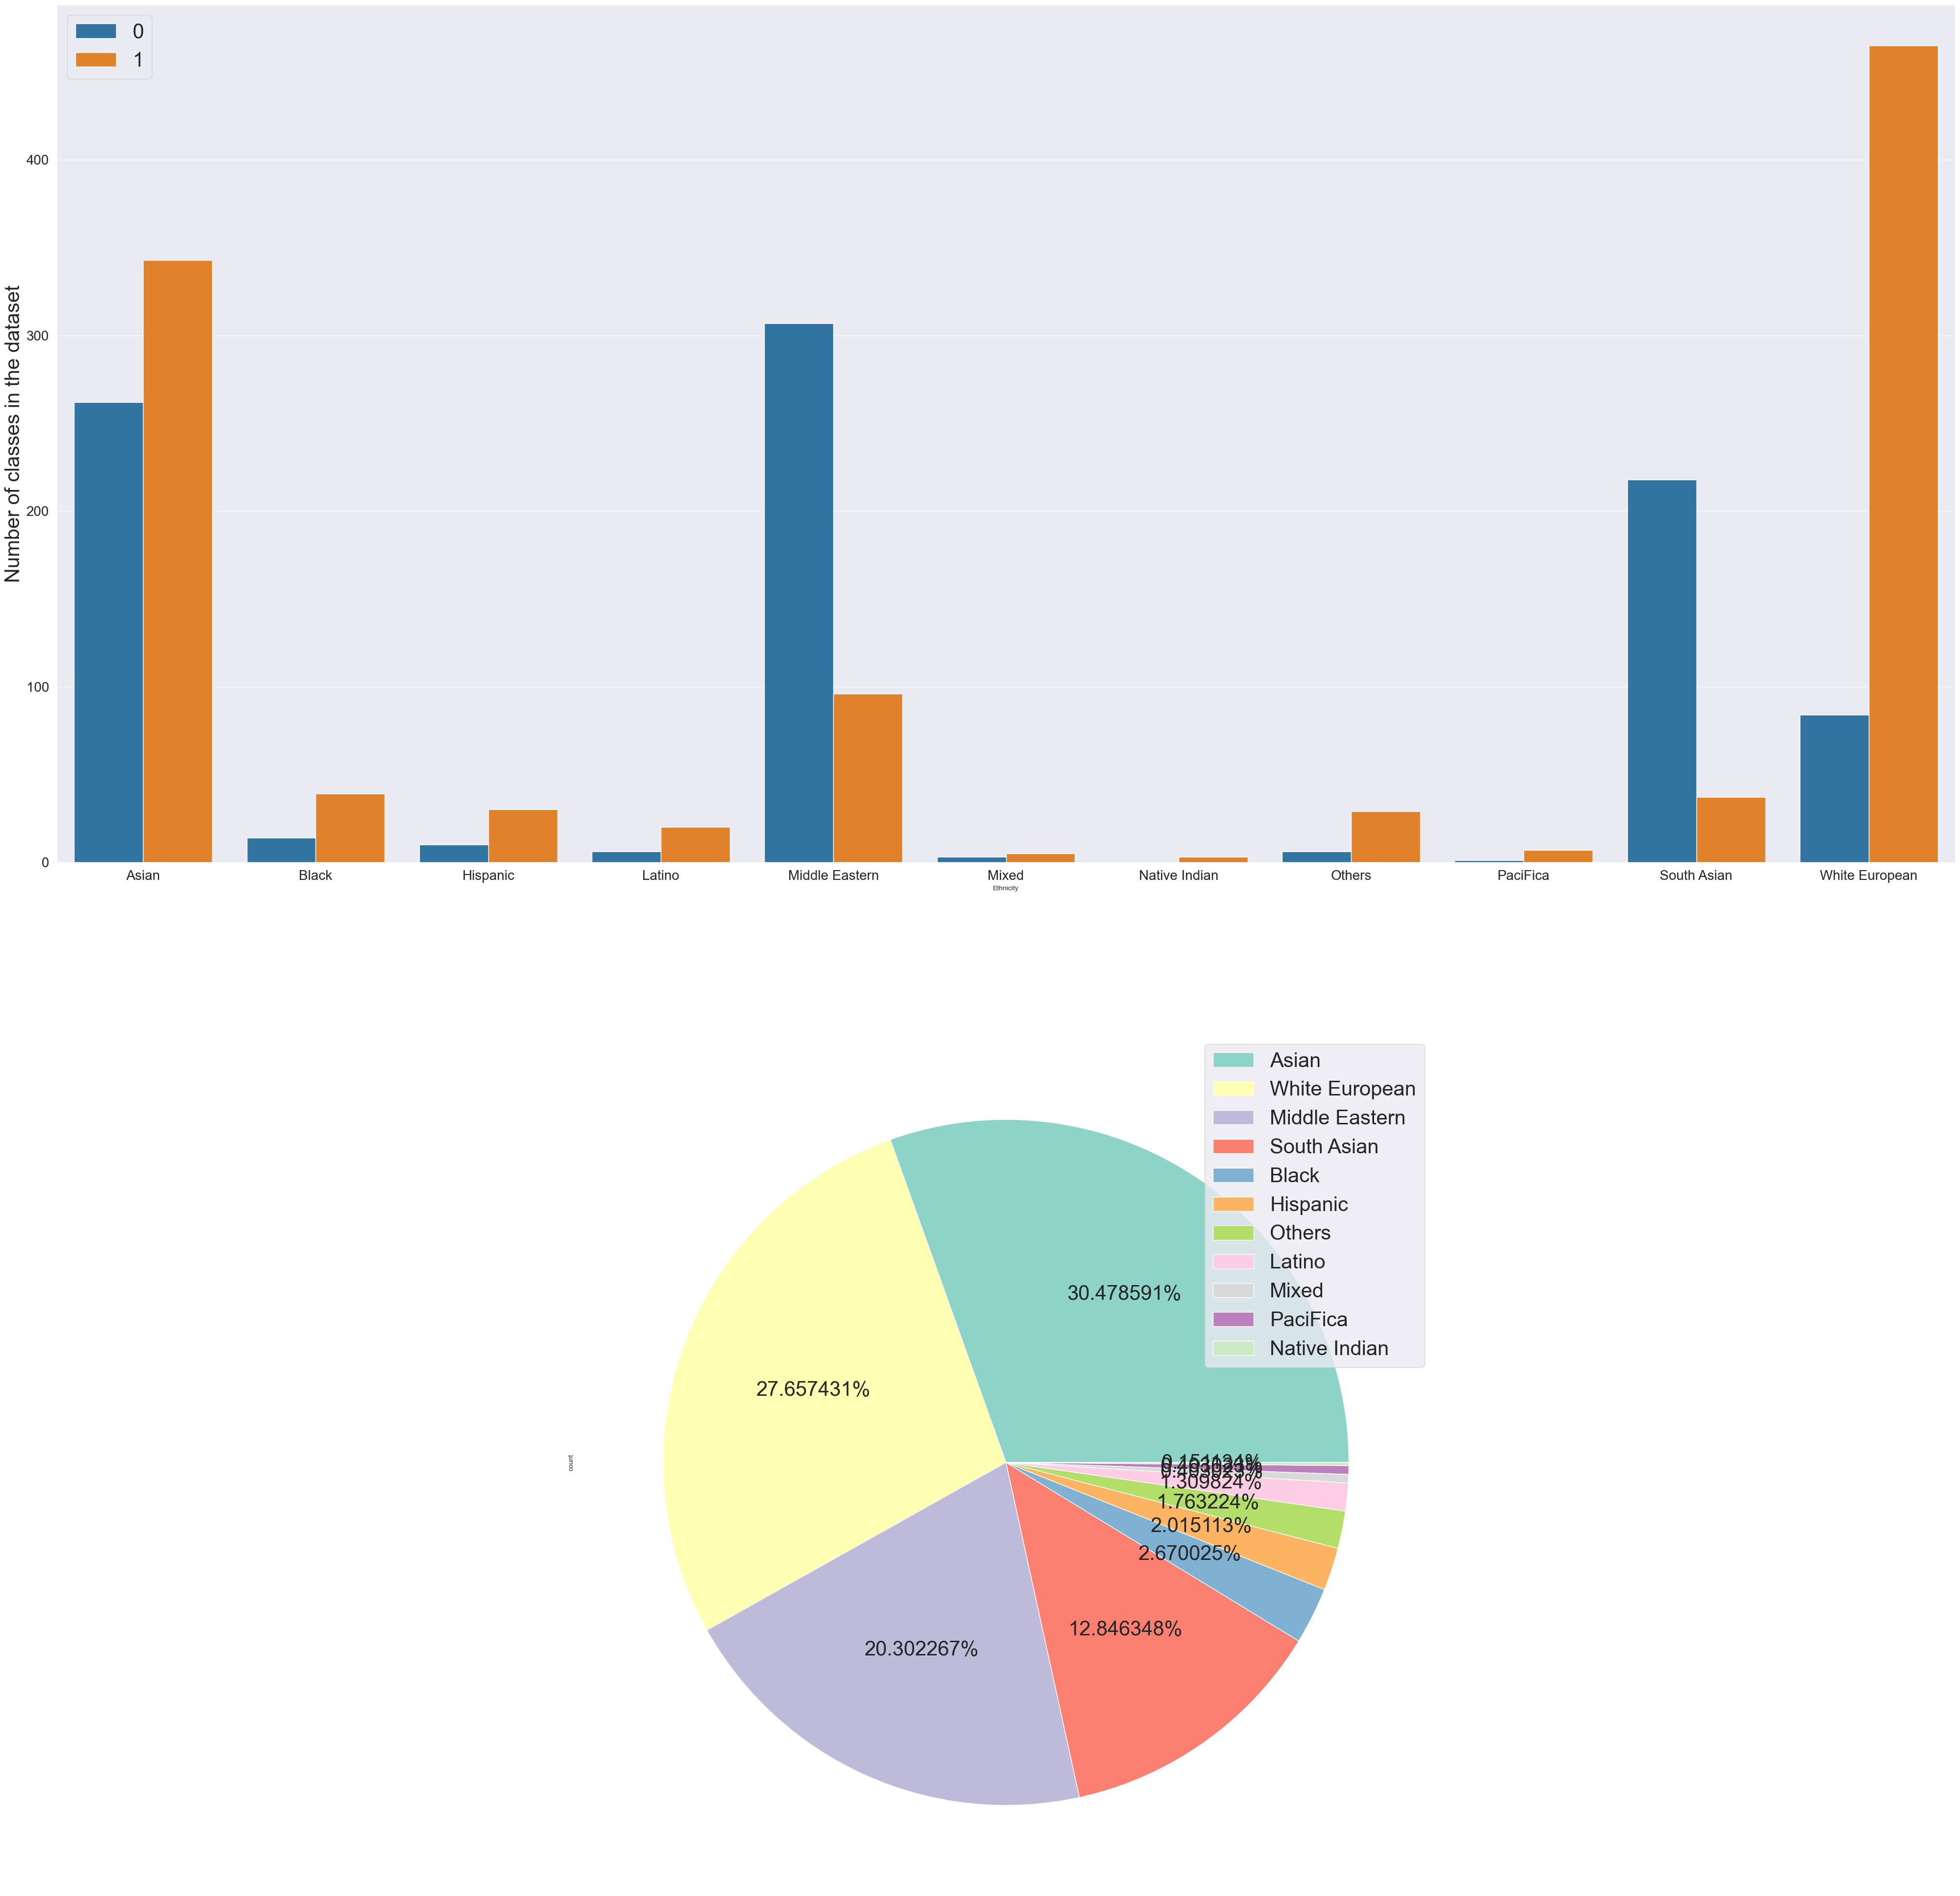

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(35, 20))  # Increase the height of the figure

# Group the data by 'Ethnicity' and 'ASD_traits' columns and count the occurrences
grouped_data = imputed_data.groupby(['Ethnicity', 'ASD_traits']).size().reset_index(name='Count')

# Plot the bar plot with hue as 'ASD_traits'
target_counts_barplot = sns.barplot(x='Ethnicity', y='Count', hue='ASD_traits', data=grouped_data, ax=ax[0])
target_counts_barplot.set_ylabel('Number of classes in the dataset', fontsize=30)  # Increase the font size
target_counts_barplot.tick_params(axis='x', labelsize=20, width=2, length=8)  # Increase x-axis number size and thickness
target_counts_barplot.tick_params(axis='y', labelsize=20, width=2, length=8)  # Increase y-axis number size and thickness


# Count the occurrences of each ethnicity in the original data
ethnicity_counts = imputed_data['Ethnicity'].value_counts()

# Specify a separate figsize for the pie chart
target_counts_pie = ethnicity_counts.plot.pie(autopct="%3f%%", ax=ax[1], colors=sns.color_palette('Set3'), figsize=(50, 50),
                                              fontsize=30, labeldistance=None)  # Increase the font size
ax[0].legend(fontsize=30)  # Increase the font size of the legend
ax[1].legend(fontsize=30)  # Increase the font size of the legend

plt.show()

# **ASD patients **

In [ ]:
imputed_data.columns

Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='object')

In [ ]:
import plotly.graph_objects as go

groups = ['Anxiety_disorder', 'Jaundice', 'Family_mem_with_ASD', 'Social/Behavioural Issues',
          'Learning disorder', 'Global developmental delay/intellectual disability',
          'Speech Delay/Language Disorder', 'Genetic_Disorders']

for col in groups:
    data = imputed_data[imputed_data['ASD_traits'] == "Yes"].groupby(col).size().reset_index(name='counts')

    fig = go.Figure(data=[go.Pie(labels=data[col], values=data['counts'])])
    fig.update_layout(title=f"<b>Count of ASD Positive - {col}</b>", title_font_size=20, width=900)
    fig.update_traces(marker=dict(colors=['#D17D49', '#36422B']))

    fig.show()


This plots kinda gives us a preview of heat map or correlation between these traits and asd positive diagnosis. Although i wanna see what's the results for non asd patients, to see if for instance jundice actually relates to autism.

In [ ]:
import plotly.graph_objects as go

groups=['Anxiety_disorder','Jaundice','Family_mem_with_ASD','Social/Behavioural Issues','Learning disorder',
        'Global developmental delay/intellectual disability','Speech Delay/Language Disorder','Genetic_Disorders']

for col in groups:
    
    data = imputed_data[imputed_data['ASD_traits'] == "No"].groupby(col).size().reset_index(name='counts')

    fig = go.Figure(data=[go.Pie(labels=data[col], values=data['counts'])])
    fig.update_layout(title = f"<b>Count of Non ASD Patients - {col}</b>", title_font_size=20, width=900)

    fig.show()


In [ ]:
groups = ['Anxiety_disorder', 'Jaundice', 'Family_mem_with_ASD', 'Social/Behavioural Issues',
          'Learning disorder', 'Global developmental delay/intellectual disability',
          'Speech Delay/Language Disorder', 'Genetic_Disorders']

data_dict = {'Index': [], 'ASD Positive': [], 'Non-ASD': []}

for col in groups:
    asd_positive_count = imputed_data[(imputed_data['ASD_traits'] == "Yes") & (imputed_data[col] =='Yes')].shape[0]
    non_asd_count = imputed_data[(imputed_data['ASD_traits'] == "No") & (imputed_data[col] =='Yes')].shape[0]

    data_dict['Index'].append(col)
    data_dict['ASD Positive'].append(asd_positive_count)
    data_dict['Non-ASD'].append(non_asd_count)

df1 = pd.DataFrame(data_dict)

# Calculate the percentage of each column relative to the other
df1['ASD Positive %'] = df1['ASD Positive'] / (df1['ASD Positive'] + df1['Non-ASD'])
df1['Non-ASD %'] = df1['Non-ASD'] / (df1['ASD Positive'] + df1['Non-ASD'])

# Apply formatting to highlight cells based on their percentage values relative to the other column
styled_df = df1.style.bar(subset=['ASD Positive %'], color='#84A9AC').bar(subset=['Non-ASD %'], color='#FDBE87')

styled_df

,Index,ASD Positive,Non-ASD,ASD Positive %,Non-ASD %
0,Anxiety_disorder,0,0,nan,nan
1,Jaundice,0,0,nan,nan
2,Family_mem_with_ASD,0,0,nan,nan
3,Social/Behavioural Issues,0,0,nan,nan
4,Learning disorder,0,0,nan,nan
5,Global developmental delay/intellectual disability,0,0,nan,nan
6,Speech Delay/Language Disorder,0,0,nan,nan
7,Genetic_Disorders,0,0,nan,nan


In [ ]:

# Filter out rows with 'YES' in the 'Class/ASD' column
asd_data = imputed_data[imputed_data['ASD_traits'] == 'Yes']

# Group the data by gender and compute the sum of each symptom column
gender_totals = asd_data.groupby('Sex').sum().iloc[:, 1:10]

# Calculate the percentage values by dividing the summed values by the row sums
percentage_data = gender_totals.div(gender_totals.sum(axis=1), axis=0) * 100

# Reshape the percentage data frame into a long format using the 'melt' function
melted_data = pd.melt(percentage_data.reset_index(), id_vars='Sex', var_name='symptom', value_name='percentage')

# Create a bar plot to visualize the percentage of symptoms by gender
fig = px.bar(melted_data, x='symptom', y='percentage', color='Sex',
             color_discrete_map={'M': 'lightblue', 'F': 'pink'})
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Filter out rows with positive ASD ('ASD_traits' = 'Yes')
positive_asd = imputed_data[imputed_data['ASD_traits'] == 'Yes']

# Filter out rows with negative ASD ('ASD_traits' = 'No')
negative_asd = imputed_data[imputed_data['ASD_traits'] == 'No']

# Create a combined DataFrame with both positive and negative ASD data
combined_df = pd.concat([positive_asd, negative_asd])

# Create a histogram using plotly express
fig = px.histogram(combined_df, x='Age_Years', color='ASD_traits',
                   nbins=int(imputed_data['Age_Years'].max()/5), range_x=[0, int(imputed_data['Age_Years'].max())],
                   labels={'Age_Years': 'Age Range'}, 
                   color_discrete_sequence=['yellow', 'green'],
                   opacity=0.7, barmode='overlay')

# Set plot properties
fig.update_layout(
    title='Histogram Distribution of Age with ASD Results',
    xaxis_title='Age Range',
    yaxis_title='Count'
)

# Show the plot
fig.show()


# **Heat map**

In [ ]:
imputed_data.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,1,1.0,1,1,0,Middle Eastern,1,0,Family member,0
1,2,1,1,0,0,0,1,1,0,0,...,1,1.0,2,1,1,White European,1,0,Family member,1
2,3,1,0,0,0,0,0,1,1,0,...,1,1.0,4,1,1,Middle Eastern,1,0,Family member,1
3,4,1,1,1,1,1,1,1,1,1,...,1,1.0,2,1,1,Hispanic,0,0,Family member,1
4,5,1,1,0,1,1,1,1,1,1,...,1,1.0,1,1,0,White European,0,0,Family member,1


In [ ]:
imputed_data.duplicated().sum()

0

In [ ]:
df_bool=imputed_data[['ASD_traits']]
num_df=imputed_data.copy()
# define a function to convert yes/no to 1/0
def convert_yes_no_to_binary(col):
    return col.eq('Yes').astype(int)

# apply the function to the columns in the dataframe
for col in df_bool:
    num_df[col] = convert_yes_no_to_binary(num_df[col])
num_df.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,1,1.0,1,1,0,Middle Eastern,1,0,Family member,0
1,2,1,1,0,0,0,1,1,0,0,...,1,1.0,2,1,1,White European,1,0,Family member,0
2,3,1,0,0,0,0,0,1,1,0,...,1,1.0,4,1,1,Middle Eastern,1,0,Family member,0
3,4,1,1,1,1,1,1,1,1,1,...,1,1.0,2,1,1,Hispanic,0,0,Family member,0
4,5,1,1,0,1,1,1,1,1,1,...,1,1.0,1,1,0,White European,0,0,Family member,0


In [ ]:
num_df['Result'] = num_df.iloc[:, 1:11].sum(axis=1)
num_df.head()


,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,Result
0,1,0,0,0,0,0,0,1,1,0,...,1.0,1,1,0,Middle Eastern,1,0,Family member,0,3
1,2,1,1,0,0,0,1,1,0,0,...,1.0,2,1,1,White European,1,0,Family member,0,4
2,3,1,0,0,0,0,0,1,1,0,...,1.0,4,1,1,Middle Eastern,1,0,Family member,0,4
3,4,1,1,1,1,1,1,1,1,1,...,1.0,2,1,1,Hispanic,0,0,Family member,0,10
4,5,1,1,0,1,1,1,1,1,1,...,1.0,1,1,0,White European,0,0,Family member,0,9


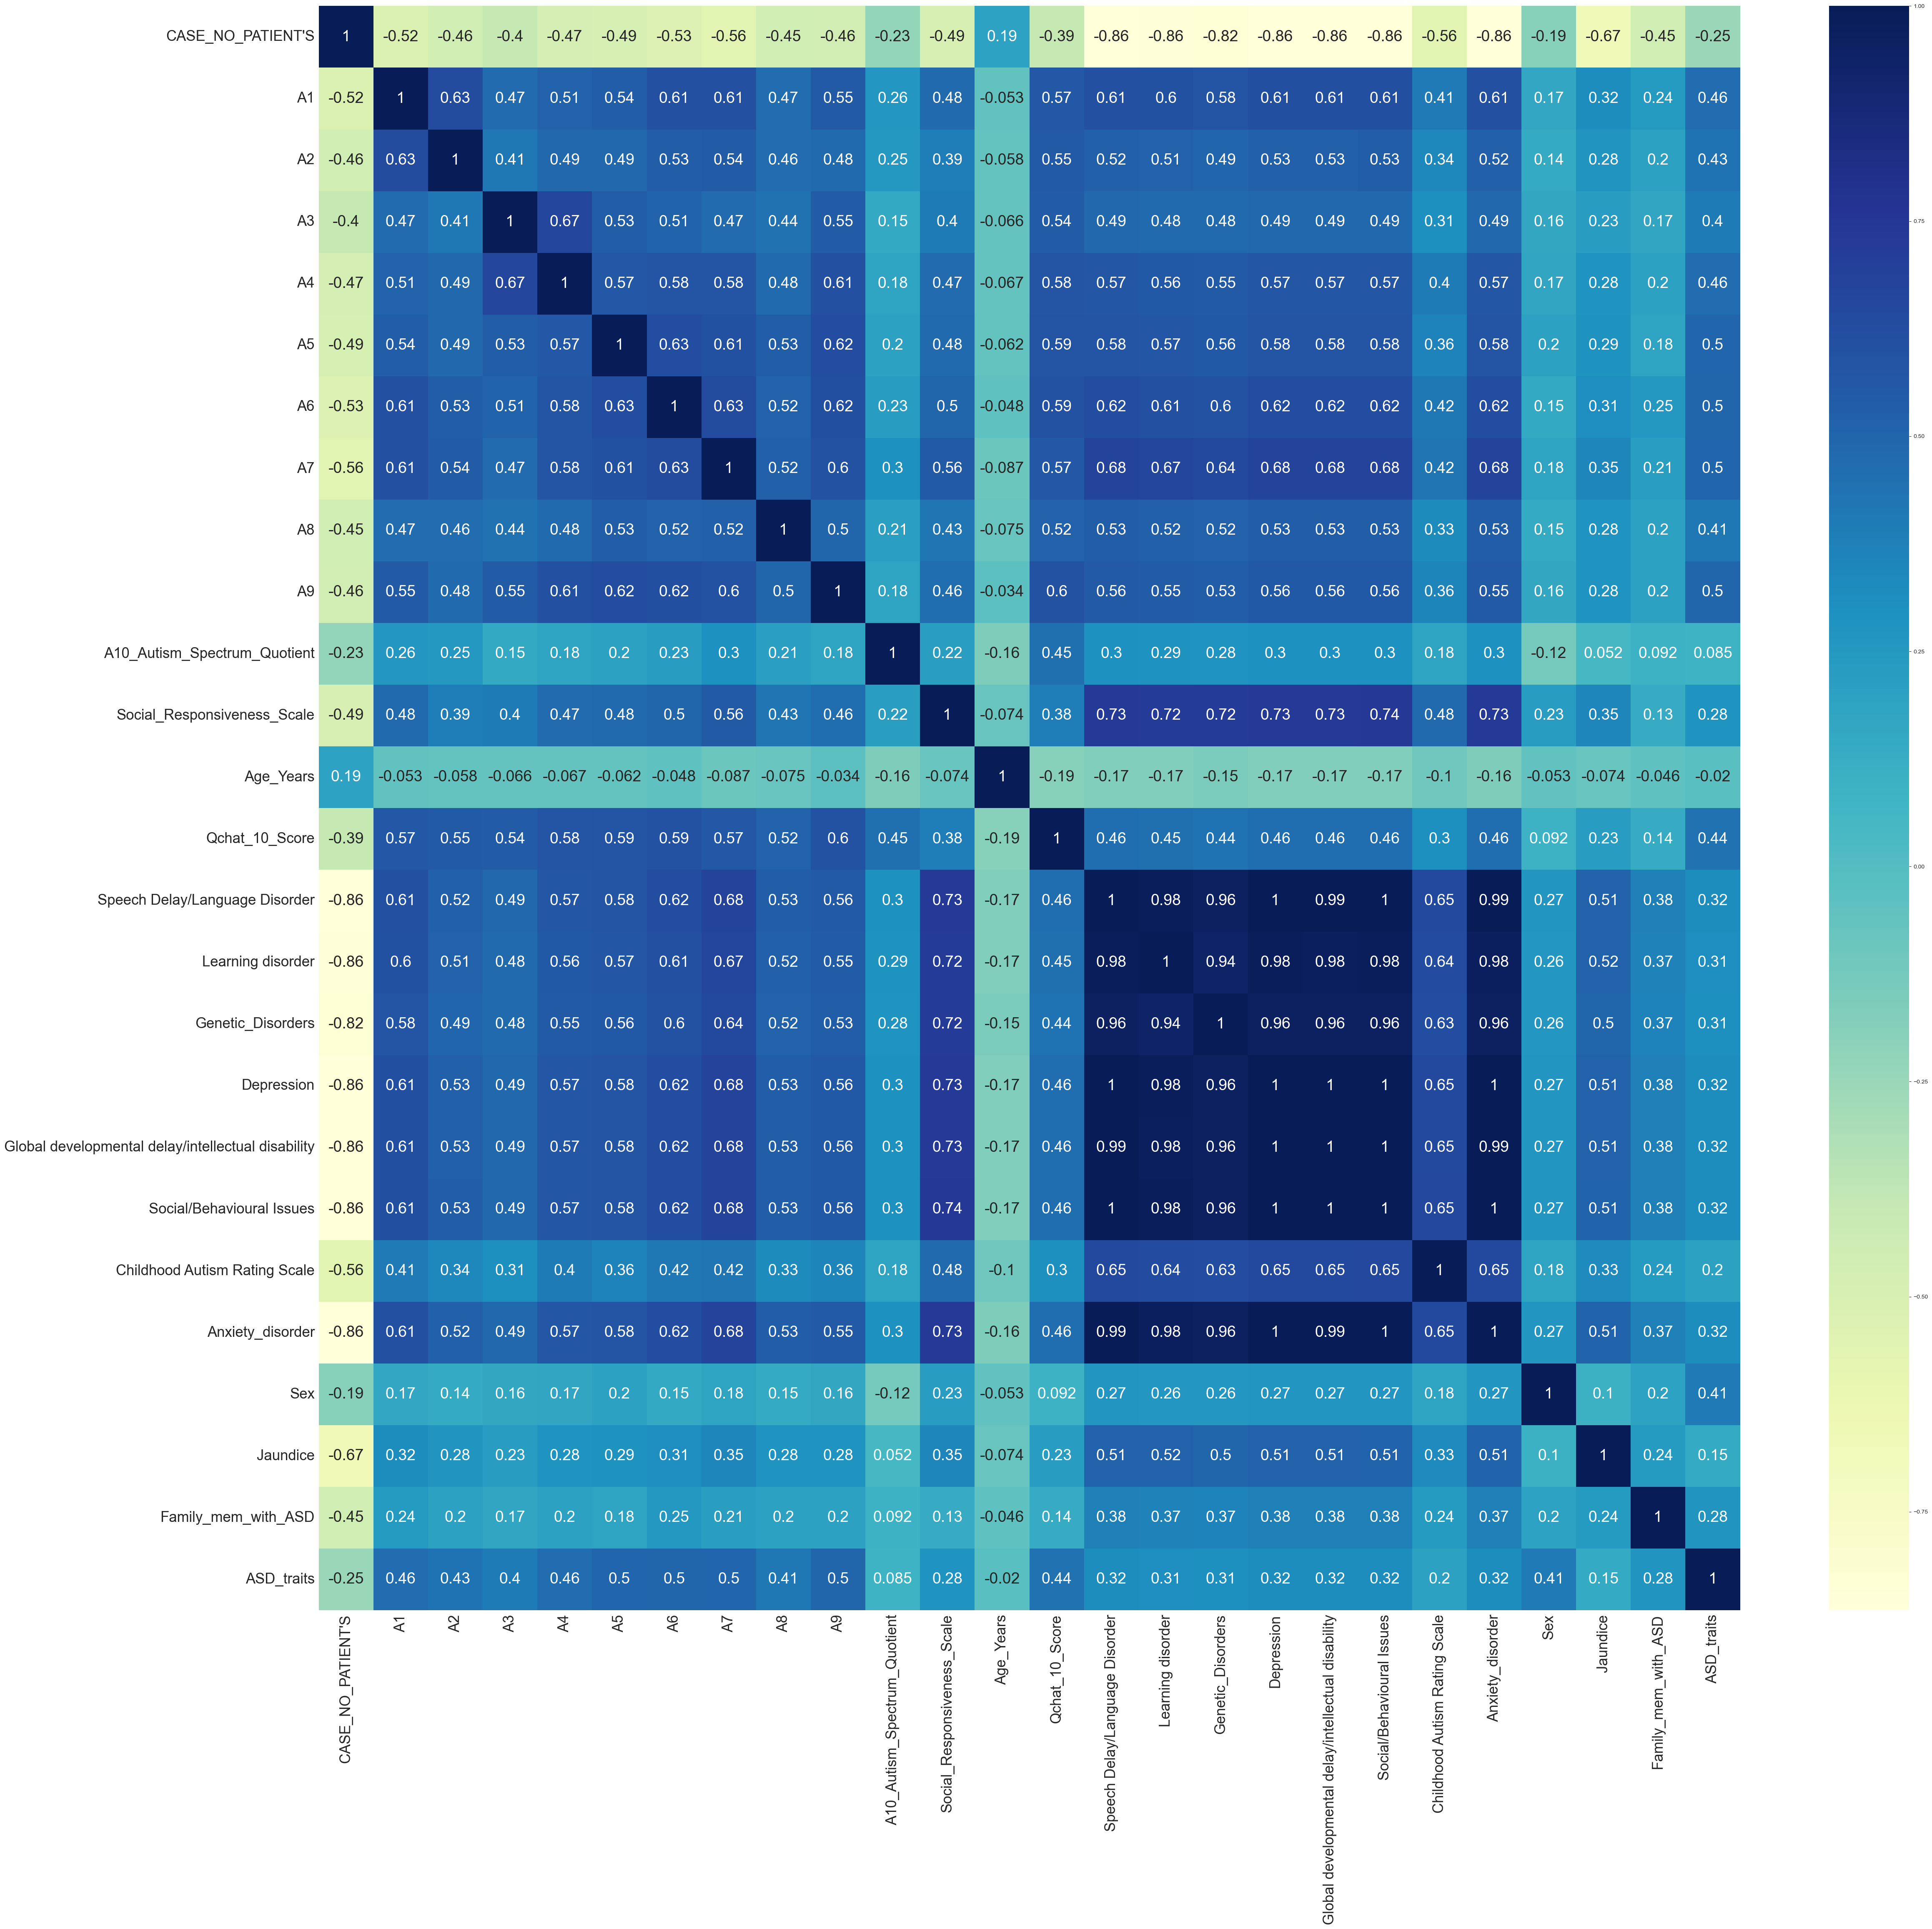

In [ ]:
# Create a dataframe with ONLY numbers first
num_df = df.select_dtypes(include=['number'])

# Then run your plotting code
plt.figure(figsize=(55,50))
ax = sns.heatmap(num_df.corr(), annot=True, cmap="YlGnBu", annot_kws={"fontsize":27})
ax.tick_params(axis='both', which='major', labelsize=27)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=25)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=25)
plt.show() # Don't forget to show it

# **Box Plot**

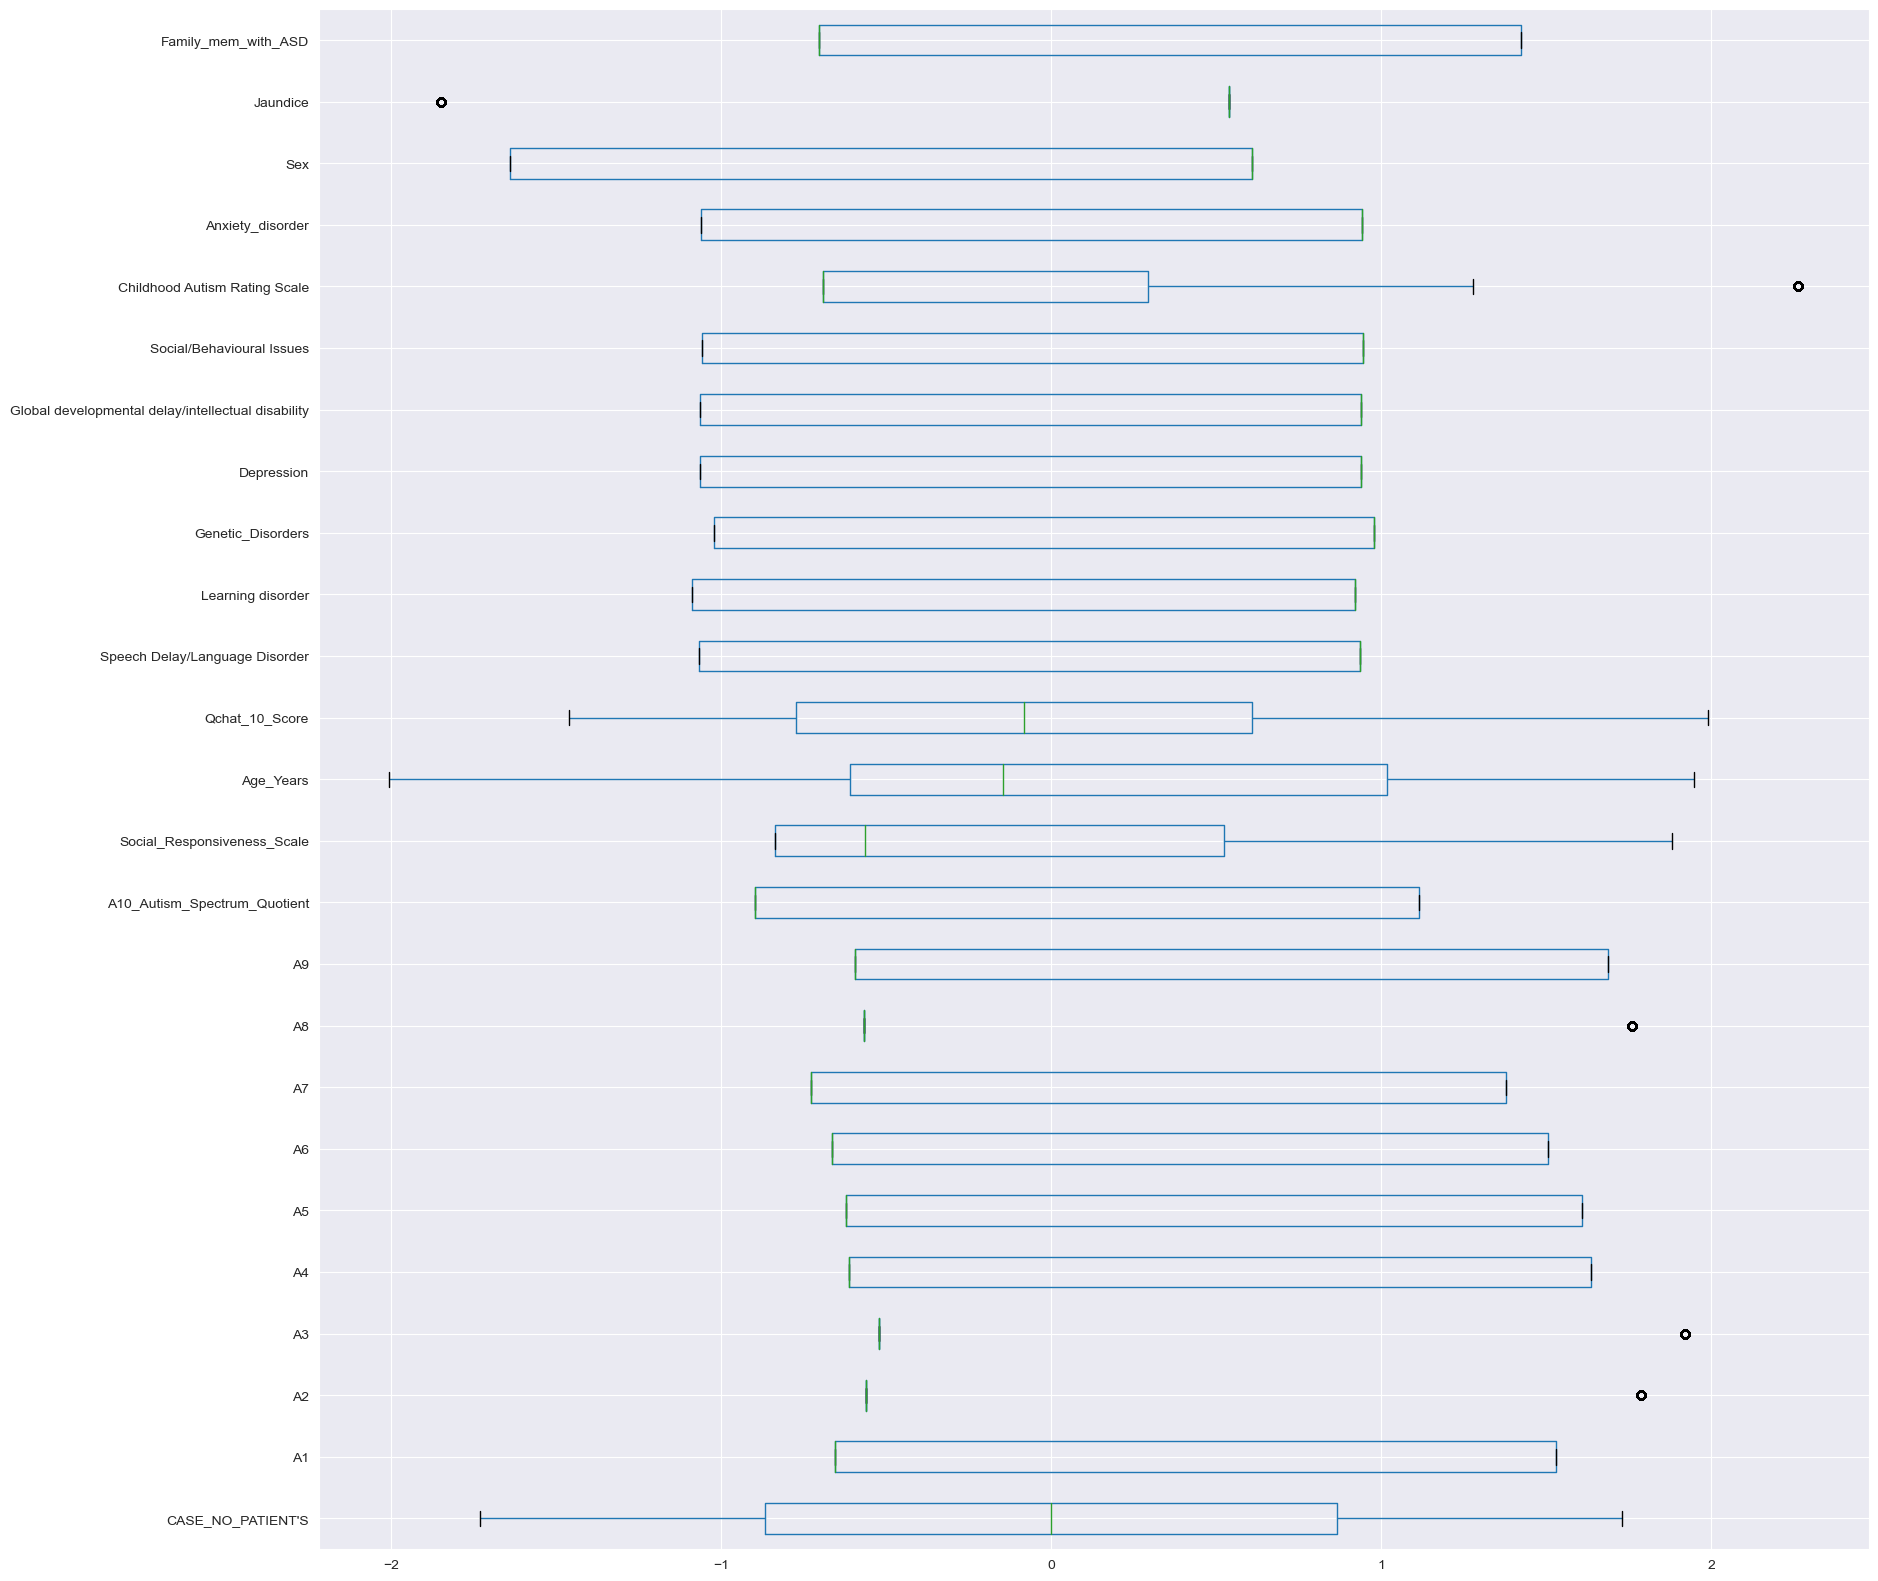

In [ ]:
from sklearn.preprocessing import StandardScaler

object_cols = num_df.select_dtypes(include=['object']).columns
features = num_df.drop(columns=object_cols).drop(columns='ASD_traits')

scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
data_boxplot = features_scaled.boxplot(return_type='dict', vert=False, figsize=(20,20))

# **Encoding**

In [ ]:
imputed_data.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,1,1.0,1,1,0,Middle Eastern,1,0,Family member,0
1,2,1,1,0,0,0,1,1,0,0,...,1,1.0,2,1,1,White European,1,0,Family member,1
2,3,1,0,0,0,0,0,1,1,0,...,1,1.0,4,1,1,Middle Eastern,1,0,Family member,1
3,4,1,1,1,1,1,1,1,1,1,...,1,1.0,2,1,1,Hispanic,0,0,Family member,1
4,5,1,1,0,1,1,1,1,1,1,...,1,1.0,1,1,0,White European,0,0,Family member,1


From the later parts we know that two columns of "Who_completed_the_test" and "Ethnicity" have more than 5 unique values, I'll use frequency method to convert them to numerican columns, then I convert yes or no answers to 0 , 1 . At last I use ordinal encod for gender.

In [ ]:
imputed_data.columns

Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits'],
      dtype='object')

In [ ]:
encod_data=imputed_data.copy()
freq1 = encod_data['Ethnicity'].value_counts(normalize=True)
freq2 = encod_data['Who_completed_the_test'].value_counts(normalize=True)

# Map the values to their frequencies
encod_data['Ethnicity_en'] = encod_data['Ethnicity'].map(freq1)
encod_data['Who_completed_the_test_en'] = encod_data['Who_completed_the_test'].map(freq2)
#removal
encod_data =encod_data.drop('Ethnicity', axis=1)
encod_data =encod_data.drop('Who_completed_the_test', axis=1)
encod_data


,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Jaundice,Family_mem_with_ASD,ASD_traits,Ethnicity_en,Who_completed_the_test_en
0,1,0,0,0,0,0,0,1,1,0,...,1,1.0,1,1,0,1,0,0,0.203023,0.360705
1,2,1,1,0,0,0,1,1,0,0,...,1,1.0,2,1,1,1,0,1,0.276574,0.360705
2,3,1,0,0,0,0,0,1,1,0,...,1,1.0,4,1,1,1,0,1,0.203023,0.360705
3,4,1,1,1,1,1,1,1,1,1,...,1,1.0,2,1,1,0,0,1,0.020151,0.360705
4,5,1,1,0,1,1,1,1,1,1,...,1,1.0,1,1,0,0,0,1,0.276574,0.360705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1609,1610,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,0,1,1,0.304786,0.621159
1632,1633,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,1,1,1,0.304786,0.014610
1646,1647,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,0,1,1,0.304786,0.621159
1669,1670,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,0,1,1,0.304786,0.621159


In [ ]:
bools=['Social_Responsiveness_Scale', 'Speech Delay/Language Disorder', 'Learning disorder', 'Genetic_Disorders', 'Depression', 'Global developmental delay/intellectual disability', 'Social/Behavioural Issues', 'Anxiety_disorder', 'Jaundice', 'Family_mem_with_ASD', 'ASD_traits']

encod_data1 = encod_data.copy()  # Make a copy of the original DataFrame

for col in bools:
    encod_data1[col] = encod_data1[col].replace({'Yes': 1, 'No': 0})

encod_data1

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Jaundice,Family_mem_with_ASD,ASD_traits,Ethnicity_en,Who_completed_the_test_en
0,1,0,0,0,0,0,0,1,1,0,...,1,1.0,1,1,0,1,0,0,0.203023,0.360705
1,2,1,1,0,0,0,1,1,0,0,...,1,1.0,2,1,1,1,0,1,0.276574,0.360705
2,3,1,0,0,0,0,0,1,1,0,...,1,1.0,4,1,1,1,0,1,0.203023,0.360705
3,4,1,1,1,1,1,1,1,1,1,...,1,1.0,2,1,1,0,0,1,0.020151,0.360705
4,5,1,1,0,1,1,1,1,1,1,...,1,1.0,1,1,0,0,0,1,0.276574,0.360705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1609,1610,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,0,1,1,0.304786,0.621159
1632,1633,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,1,1,1,0.304786,0.014610
1646,1647,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,0,1,1,0.304786,0.621159
1669,1670,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,0,1,1,0.304786,0.621159


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Initialize the encoder
encoder = OrdinalEncoder()

# Fit and transform the data
enc = encoder.fit_transform(encod_data1["Sex"].values.reshape(-1, 1))

# Convert the encoded data back to a dataframe
encoded_df = pd.DataFrame(enc, columns=['Sex_en'])

encoded_data= pd.concat([encod_data1,encoded_df], axis=1)
encoded_data.drop('Sex', axis=1,inplace=True)
encoded_data.drop(encoded_data.columns[0], axis=1,inplace=True)
encoded_data


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Jaundice,Family_mem_with_ASD,ASD_traits,Ethnicity_en,Who_completed_the_test_en,Sex_en
0,0,0,0,0,0,0,1,1,0,1,...,1,1.0,1,1,1,0,0,0.203023,0.360705,0.0
1,1,1,0,0,0,1,1,0,0,0,...,1,1.0,2,1,1,0,1,0.276574,0.360705,1.0
2,1,0,0,0,0,0,1,1,0,1,...,1,1.0,4,1,1,0,1,0.203023,0.360705,1.0
3,1,1,1,1,1,1,1,1,1,1,...,1,1.0,2,1,0,0,1,0.020151,0.360705,1.0
4,1,1,0,1,1,1,1,1,1,1,...,1,1.0,1,1,0,0,1,0.276574,0.360705,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1609,0,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,0,1,1,0.304786,0.621159,0.0
1632,0,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,1,1,1,0.304786,0.014610,1.0
1646,0,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,0,1,1,0.304786,0.621159,1.0
1669,0,0,0,0,0,0,0,0,0,0,...,0,0.0,1,0,0,1,1,0.304786,0.621159,0.0


===  (ASD Yes/No from the 10Q) ===
Accuracy: 0.7967806841046278
              precision    recall  f1-score   support

           0       0.70      0.97      0.81       228
           1       0.97      0.65      0.78       269

    accuracy                           0.80       497
   macro avg       0.83      0.81      0.79       497
weighted avg       0.84      0.80      0.79       497



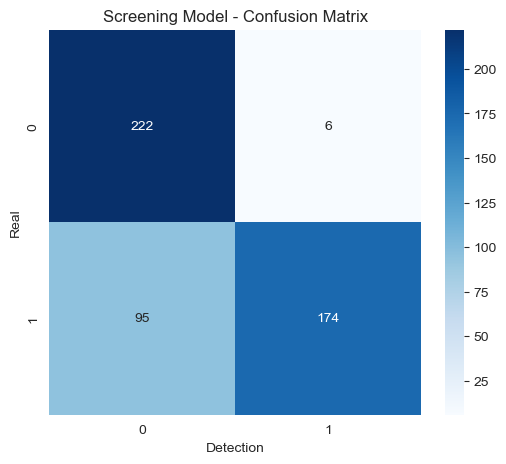

In [ ]:
# ============= نموذج الفحص السريع (Screening Model) =============
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = encoded_data[['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10_Autism_Spectrum_Quotient']]
y = encoded_data['ASD_traits']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model_screen = RandomForestClassifier(n_estimators=200, random_state=42)
model_screen.fit(X_train, y_train)
y_pred = model_screen.predict(X_test)

print("===  (ASD Yes/No from the 10Q) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Screening Model - Confusion Matrix')
plt.ylabel('Real')
plt.xlabel('Detection')
plt.show()
#meeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Create a copy of your dataframe to avoid modifying the original 'df'
encoded_data = df.copy()

# 2. Check if 'Age' exists and rename it to 'Age_Years' if needed
if 'Age' in encoded_data.columns:
    encoded_data.rename(columns={'Age': 'Age_Years'}, inplace=True)

# 3. Create a dictionary to map "Yes"/"No" to 1/0
binary_mapping = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'M': 1, 'F': 0, 'm': 1, 'f': 0}

# List of columns that are likely Yes/No questions
binary_cols = [
    'Jaundice', 'Family_mem_with_ASD', 'Speech Delay/Language Disorder',
    'Learning disorder', 'Genetic_Disorders', 'Depression', 'Anxiety_disorder',
    'Global developmental delay/intellectual disability', 'Social/Behavioural Issues'
]

# Apply mapping to binary columns (fill NaNs with 0 or mode if necessary)
for col in binary_cols:
    if col in encoded_data.columns:
        encoded_data[col] = encoded_data[col].map(binary_mapping).fillna(0)

# 4. Create the '_en' (Encoded) columns using Label Encoder
categorical_cols = ['Sex', 'Ethnicity', 'Who_completed_the_test']
le = LabelEncoder()

for col in categorical_cols:
    if col in encoded_data.columns:
        # Fill missing values and convert to string to avoid errors
        encoded_data[col] = encoded_data[col].fillna('Unknown').astype(str)
        # Create the new column with name like 'Sex_en'
        encoded_data[f'{col}_en'] = le.fit_transform(encoded_data[col])

# 5. Ensure Target column is integer type
if 'Childhood Autism Rating Scale' in encoded_data.columns:
    encoded_data['Childhood Autism Rating Scale'] = encoded_data['Childhood Autism Rating Scale'].astype(int)

print("Data encoded successfully! Now you can run your model code.")

Data encoded successfully! Now you can run your model code.


The data is ready to be modelled.

This special dataset will be used for another modelling method.

In [ ]:
# Create a copy of the encoded data
df_v1 = encoded_data.copy()

# Sum the Result columns (A1-A10), ensuring we only sum numbers
# We use select_dtypes(include=['number']) to avoid errors if non-numeric columns are present
df_v1['Result'] = df_v1.iloc[:, 0:10].select_dtypes(include=['number']).sum(axis=1)

# Sum the Other signs columns, ensuring we only sum numbers
# This fixes the TypeError: unsupported operand type(s) for +: 'float' and 'str'
df_v1['Other_signs'] = df_v1.iloc[:, 11:23].select_dtypes(include=['number']).sum(axis=1)

# Display the first few rows to verify
df_v1.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,Sex_en,Ethnicity_en,Who_completed_the_test_en,Result,Other_signs
0,1,0,0,0,0,0,0,1,1,0,...,Middle Eastern,0.0,0.0,Family member,0,0,4,0,3,9.0
1,2,1,1,0,0,0,1,1,0,0,...,White European,0.0,0.0,Family member,1,1,10,0,6,15.0
2,3,1,0,0,0,0,0,1,1,0,...,Middle Eastern,0.0,0.0,Family member,1,1,4,0,6,18.0
3,4,1,1,1,1,1,1,1,1,1,...,Hispanic,0.0,0.0,Family member,1,1,2,0,13,15.0
4,5,1,1,0,1,1,1,1,1,1,...,White European,0.0,0.0,Family member,1,0,10,0,13,15.0


# **Modelling** 
# **with encoded data or real data**

In [ ]:
import warnings
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, PowerTransformer, Normalizer

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

def ignore_warn(*args, **kwargs):
    pass
warnings.warn = ignore_warn
encoded_data.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits,Sex_en,Ethnicity_en,Who_completed_the_test_en
0,1,0,0,0,0,0,0,1,1,0,...,0.0,0,Middle Eastern,0.0,0.0,Family member,0,0,4,0
1,2,1,1,0,0,0,1,1,0,0,...,0.0,1,White European,0.0,0.0,Family member,1,1,10,0
2,3,1,0,0,0,0,0,1,1,0,...,0.0,1,Middle Eastern,0.0,0.0,Family member,1,1,4,0
3,4,1,1,1,1,1,1,1,1,1,...,0.0,1,Hispanic,0.0,0.0,Family member,1,1,2,0
4,5,1,1,0,1,1,1,1,1,1,...,0.0,0,White European,0.0,0.0,Family member,1,0,10,0


In [ ]:
X = encoded_data.drop('ASD_traits',axis=1)
y = encoded_data.iloc[:, 23]
X.columns = X.columns.astype(str)

In [ ]:
# 1. Define X and y using your pre-processed 'encoded_data' dataframe
# Make sure to drop the target column and any non-numeric columns from X
X = encoded_data.drop(['Childhood Autism Rating Scale', 'Case_No', 'Who_completed_the_test', 'Ethnicity', 'Sex'], axis=1, errors='ignore')

# Or, explicitly select the feature columns you WANT to use (SAFE method)
features = [
    'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 
    'Age_Years', 'Result', 'Other_signs', 'Sex_en', 'Ethnicity_en', 'Who_completed_the_test_en', 'Jaundice', 'Family_mem_with_ASD'
]
# Only keep columns that actually exist in your dataframe
existing_features = [col for col in features if col in encoded_data.columns]
X = encoded_data[existing_features]

# Define y (Target)
y = encoded_data['Childhood Autism Rating Scale']

# 2. Resplit the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Now run your model loop (copy-paste your loop here)
# ...

In [ ]:
Best_models = [DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators), SVC(C=1.0, kernel='rbf',degree=3, gamma='scale'),
    AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=None),
        n_estimators=n_estimators
    )]
Best_models_names = ['DecisionTreeClassifier','RandomForestClassifier','ExtraTreesClassifier',
         'SupportVectorMachine','AdaBoostClassifier']

# **Blanacing data**
under-sampling

In [ ]:
encoded_data.iloc[:,-1].value_counts()

Who_completed_the_test_en
1    1233
0     716
3      29
4       4
2       3
Name: count, dtype: int64

In [ ]:
# Check what values are actually there
counts = encoded_data.iloc[:,-1].value_counts()
print(counts)

# If you specifically want to access the counts for specific classes:
# (Assuming classes are 0 and 1, though your error suggests otherwise)
# class_count_0 = counts[0]
# class_count_1 = counts[1]

Who_completed_the_test_en
1    1233
0     716
3      29
4       4
2       3
Name: count, dtype: int64


In [ ]:
print(encoded_data.columns)


Index(['CASE_NO_PATIENT'S', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
       'A9', 'A10_Autism_Spectrum_Quotient', 'Social_Responsiveness_Scale',
       'Age_Years', 'Qchat_10_Score', 'Speech Delay/Language Disorder',
       'Learning disorder', 'Genetic_Disorders', 'Depression',
       'Global developmental delay/intellectual disability',
       'Social/Behavioural Issues', 'Childhood Autism Rating Scale',
       'Anxiety_disorder', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who_completed_the_test', 'ASD_traits', 'Sex_en',
       'Ethnicity_en', 'Who_completed_the_test_en'],
      dtype='object')


In [ ]:
class_0 = encoded_data[encoded_data["Sex_en"] == 0]
class_1 = encoded_data[encoded_data["Sex_en"] == 1]


In [ ]:
target_col = encoded_data.columns[-1]

# 1. Split data based on 'No' and 'Yes'
class_0 = encoded_data[encoded_data[target_col] == 'No']
class_1 = encoded_data[encoded_data[target_col] == 'Yes']

# 2. Get the count of the smaller class (usually 'Yes'/Class 1)
class_count_1 = len(class_1)

# 3. Sample from 'No' to match count of 'Yes'
class_0_under = class_0.sample(class_count_1, random_state=42)

# 4. Combine
test_under = pd.concat([class_0_under, class_1], axis=0)
print(test_under[target_col].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
data_under = pd.concat([class_0_under, class_1], axis = 0).reset_index().drop("index", axis = 1)
data_under.iloc[:,-1].value_counts()

Series([], Name: count, dtype: int64)

# **Modelling**
# **With under_sampled data**

In [ ]:
X = data_under.iloc[:, :-1]
y = data_under.iloc[:, -1:]
X.columns = X.columns.astype(str)

In [ ]:
# 1. Use the BALANCED dataset you created (test_under)
# Define X (features) - Drop the target column and any non-numeric ID columns
X = test_under.drop(['Case_No', 'Who_completed_the_test', 'Ethnicity', 'Sex', 'Childhood Autism Rating Scale', 'ASD_traits'], axis=1, errors='ignore')

# Alternatively, select specific numeric columns if you want to be safe:
# X = test_under[['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Years', 'Result', 'Other_signs', 'Sex_en', 'Ethnicity_en']]

# Define y (Target) - Use the last column
y = test_under.iloc[:, -1]

# 2. Check if data exists
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

if len(X) > 0:
    # 3. Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    print("Data split successfully. You can now run the model loop.")
else:
    print("Error: X is empty. Please check your 'test_under' dataframe creation step.")

X shape: (0, 26)
y shape: (0,)
Error: X is empty. Please check your 'test_under' dataframe creation step.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn import metrics

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

n_estimators = 50
names = ['DecisionTreeClassifier', 'RandomForestClassifier', 'ExtraTreesClassifier',
         'SupportVectorMachine', 'AdaBoostClassifier','KNearestNeighbor','NaiveBayes','SGDClassifier']
models = [
    DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators), SVC(C=1.0, kernel='rbf',degree=10, gamma='scale'),
    AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=None),
        n_estimators=n_estimators
    ),KNeighborsClassifier(n_neighbors=3),GaussianNB(), SGDClassifier()
    
]
 # no of degree10//
for counter, model in enumerate(models):
    # Convert y_train and y_test to 1-dimensional arrays
    y_train_flat = np.ravel(y_train)
    y_test_flat = np.ravel(y_test)
    
    # Train the model
    model.fit(X_train, y_train_flat)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    mae=mean_absolute_error(y_test_flat, y_pred)
    accuracy = metrics.accuracy_score(y_test_flat, y_pred)
    f1 = f1_score(y_test_flat, y_pred)import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. READ FRESH DATA (To clear any previous mistakes)
# Replace path if needed, or assume df is already loaded
if 'df' not in locals():
    # If df isn't loaded, try to load it. 
    # If df IS loaded, skip this.
    pass 

# 2. ENCODE DATA CORRECTLY
encoded_data = df.copy()

# Rename Age if needed
if 'Age' in encoded_data.columns:
    encoded_data.rename(columns={'Age': 'Age_Years'}, inplace=True)

# Map Binary Columns (Yes/No -> 1/0)
binary_mapping = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'M': 1, 'F': 0, 'm': 1, 'f': 0}
binary_cols = ['Jaundice', 'Family_mem_with_ASD', 'Speech Delay/Language Disorder', 
               'Learning disorder', 'Genetic_Disorders', 'Depression', 'Anxiety_disorder', 
               'Global developmental delay/intellectual disability', 'Social/Behavioural Issues', 'ASD_traits']

for col in binary_cols:
    if col in encoded_data.columns:
        encoded_data[col] = encoded_data[col].map(binary_mapping).fillna(0)

# Label Encode Categorical Columns
categorical_cols = ['Sex', 'Ethnicity', 'Who_completed_the_test']
le = LabelEncoder()
for col in categorical_cols:
    if col in encoded_data.columns:
        encoded_data[col] = encoded_data[col].astype(str)
        encoded_data[f'{col}_en'] = le.fit_transform(encoded_data[col])

# Create calculated columns (Numeric sum only)
encoded_data['Result'] = encoded_data[['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10']].sum(axis=1)
other_signs_cols = [c for c in binary_cols if c != 'ASD_traits']
encoded_data['Other_signs'] = encoded_data[other_signs_cols].sum(axis=1)

# 3. BALANCE DATA (Under-sampling)
# Assuming target is 'ASD_traits'
target_col = 'ASD_traits' 
class_0 = encoded_data[encoded_data[target_col] == 0]
class_1 = encoded_data[encoded_data[target_col] == 1]

# Safely sample
min_count = min(len(class_0), len(class_1))
class_0_under = class_0.sample(min_count, random_state=42)
class_1_under = class_1.sample(min_count, random_state=42)
test_under = pd.concat([class_0_under, class_1_under], axis=0)

# 4. DEFINE X AND y FOR TRAINING
# Select ONLY numeric feature columns
features = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 
            'Age_Years', 'Result', 'Other_signs', 'Sex_en', 'Ethnicity_en', 
            'Who_completed_the_test_en', 'Jaundice', 'Family_mem_with_ASD']

X = test_under[features]
y = test_under[target_col]

# 5. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data successfully prepared!")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
    print("Accuracy " + names[counter] + ":", accuracy)
    print("F1 " + names[counter] + ":", f1,'\n')

SyntaxError: invalid syntax (1230415513.py, line 36)

SMOTE

In [ ]:
! pip install imblearn

  Obtaining dependency information for imblearn from https://files.pythonhosted.org/packages/81/a7/4179e6ebfd654bd0eac0b9c06125b8b4c96a9d0a8ff9e9507eb2a26d2d7e/imblearn-0.0-py2.py3-none-any.whl.metadata


In [ ]:
from imblearn.over_sampling import SMOTE

ImportError: cannot import name '_MissingValues' from 'sklearn.utils._param_validation' (d:\python\Lib\site-packages\sklearn\utils\_param_validation.py)

In [ ]:
#build SMOTE
smote = SMOTE()

#seperate values
X2 = encoded_data.iloc[:,:-1]
Y2 = encoded_data.iloc[:,-1]

#Scaling Features for the Filter method
mm = MinMaxScaler()
X_mm = mm.fit_transform(X2)
df_x2 = pd.DataFrame(X_mm, columns = X2.columns)
df_mm = pd.concat([df_x2, Y2], axis = 1)

#fit the X and Y on SMOTE
x_smote, y_smote = smote.fit_resample(df_x2, Y2)

#Finalization
x_smote_df = pd.DataFrame(x_smote, columns = df_x2.columns)
y_smote_df = pd.DataFrame(y_smote)
data_smote = pd.concat([x_smote_df,y_smote_df], axis = 1)

# **Modelling**
# **With SMOTE balanced data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn import metrics

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

n_estimators = 50
names = ['DecisionTreeClassifier', 'RandomForestClassifier', 'ExtraTreesClassifier',
         'SupportVectorMachine', 'AdaBoostClassifier','KNearestNeighbor','NaiveBayes','SGDClassifier']
models = [
    DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators), SVC(C=1.0, kernel='rbf',degree=10, gamma='scale'),
    AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=None),
        n_estimators=n_estimators
    ),KNeighborsClassifier(n_neighbors=3),GaussianNB(), SGDClassifier()
    
]

for counter, model in enumerate(models):
    # Convert y_train and y_test to 1-dimensional arrays
    y_train_flat = np.ravel(y_train)
    y_test_flat = np.ravel(y_test)
    
    # Train the model
    model.fit(X_train, y_train_flat)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    mae=mean_absolute_error(y_test_flat, y_pred)
    accuracy = metrics.accuracy_score(y_test_flat, y_pred)
    f1 = f1_score(y_test_flat, y_pred)
    print("Accuracy " + names[counter] + ":", accuracy)
    print("F1 " + names[counter] + ":", f1,'\n')

Accuracy DecisionTreeClassifier: 0.6426174496644296
F1 DecisionTreeClassifier: 0.7554535017221584 

Accuracy RandomForestClassifier: 0.6677852348993288
F1 RandomForestClassifier: 0.7870967741935484 

Accuracy ExtraTreesClassifier: 0.6677852348993288
F1 ExtraTreesClassifier: 0.7833698030634574 

Accuracy SupportVectorMachine: 0.7197986577181208
F1 SupportVectorMachine: 0.8370731707317073 

Accuracy AdaBoostClassifier: 0.6761744966442953
F1 AdaBoostClassifier: 0.7890710382513662 

Accuracy KNearestNeighbor: 0.6577181208053692
F1 KNearestNeighbor: 0.7753303964757708 

Accuracy NaiveBayes: 0.639261744966443
F1 NaiveBayes: 0.7137150466045272 

Accuracy SGDClassifier: 0.6409395973154363
F1 SGDClassifier: 0.7146666666666667 



# **Modelling**
# **with created data of sum scores and symptoms**

In [ ]:
df_v1.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,...,Childhood Autism Rating Scale,Anxiety_disorder,Jaundice,Family_mem_with_ASD,ASD_traits,Ethnicity_en,Who_completed_the_test_en,Sex_en,Result,Other_signs
0,0,0,0,0,0,0,1,1,0,1,...,1,1,1,0,0,0.203023,0.360705,0.0,3,14.0
1,1,1,0,0,0,1,1,0,0,0,...,2,1,1,0,1,0.276574,0.360705,1.0,4,17.0
2,1,0,0,0,0,0,1,1,0,1,...,4,1,1,0,1,0.203023,0.360705,1.0,4,19.0
3,1,1,1,1,1,1,1,1,1,1,...,2,1,0,0,1,0.020151,0.360705,1.0,10,20.0
4,1,1,0,1,1,1,1,1,1,1,...,1,1,0,0,1,0.276574,0.360705,0.0,9,18.0


In [ ]:
X = df_v1.iloc[:,24:]
y = df_v1.iloc[:, 23]
X.columns = X.columns.astype(str)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn import metrics

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

n_estimators = 50
names = ['DecisionTreeClassifier', 'RandomForestClassifier', 'ExtraTreesClassifier',
         'SupportVectorMachine', 'AdaBoostClassifier','KNearestNeighbor','NaiveBayes','SGDClassifier']
models = [
    DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators), SVC(C=1.0, kernel='rbf',degree=10, gamma='scale'),
    AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=None),
        n_estimators=n_estimators
    ),KNeighborsClassifier(n_neighbors=3),GaussianNB()
    
]

for counter, model in enumerate(models):
    # Convert y_train and y_test to 1-dimensional arrays
    y_train_flat = np.ravel(y_train)
    y_test_flat = np.ravel(y_test)
    
    # Train the model
    model.fit(X_train, y_train_flat)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    mae=mean_absolute_error(y_test_flat, y_pred)
    accuracy = metrics.accuracy_score(y_test_flat, y_pred)
    f1 = f1_score(y_test_flat, y_pred)
    print("Accuracy " + names[counter] + ":", accuracy)
    print("F1 " + names[counter] + ":", f1,'\n')

Accuracy DecisionTreeClassifier: 0.9463087248322147
F1 DecisionTreeClassifier: 0.9515151515151514 

Accuracy RandomForestClassifier: 0.9446308724832215
F1 RandomForestClassifier: 0.950375939849624 

Accuracy ExtraTreesClassifier: 0.947986577181208
F1 ExtraTreesClassifier: 0.9531013615733738 

Accuracy SupportVectorMachine: 0.8120805369127517
F1 SupportVectorMachine: 0.7985611510791367 

Accuracy AdaBoostClassifier: 0.947986577181208
F1 AdaBoostClassifier: 0.9531013615733738 

Accuracy KNearestNeighbor: 0.9093959731543624
F1 KNearestNeighbor: 0.9181818181818182 

Accuracy NaiveBayes: 0.7651006711409396
F1 NaiveBayes: 0.768976897689769 



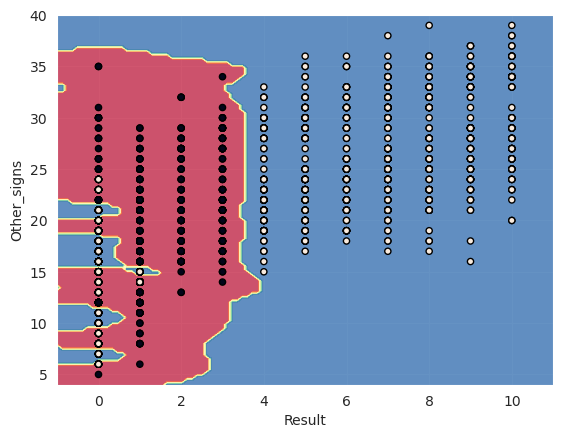

In [ ]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

X = df_v1.iloc[:, [27, 28]]  # Select the desired columns for plotting using column indices
y = df_v1.iloc[:, 23]

# Build the model
svm = SVC(kernel="rbf", gamma=0.5, C=1.0)
# Train the model
svm.fit(X, y)

# Plot Decision Boundary
DecisionBoundaryDisplay.from_estimator(
    svm,
    X,
    response_method="predict",
    cmap=plt.cm.Spectral,
    alpha=0.8,
)

# Scatter plot
plt.scatter(X.iloc[:, 0], X.iloc[:, 1],
            c=y,
            s=20, edgecolors="k")
plt.show()

# **Modelling**
# **With scaled data of sums**

In [ ]:
df_v2 = df_v1.iloc[:, [23, 24, 25, 26, 27, 28]]

In [ ]:
# import module
from sklearn.preprocessing import MinMaxScaler

# scale features
scaler = MinMaxScaler()
model=scaler.fit(df_v2)
scaled_df=model.transform(df_v2)
 
# print scaled features
print(scaled_df)

[[0.         0.66445183 0.5796748  0.         0.3        0.26470588]
 [1.         0.90697674 0.5796748  1.         0.4        0.35294118]
 [1.         0.66445183 0.5796748  1.         0.4        0.41176471]
 ...
 [1.         1.         1.         1.         0.         0.38235294]
 [1.         1.         1.         0.         0.         0.41176471]
 [1.         1.         1.         0.         0.         0.32352941]]


In [ ]:
df_v3 = pd.DataFrame(scaled_df, columns = df_v2.columns)
df_v3

,ASD_traits,Ethnicity_en,Who_completed_the_test_en,Sex_en,Result,Other_signs
0,0.0,0.664452,0.579675,0.0,0.3,0.264706
1,1.0,0.906977,0.579675,1.0,0.4,0.352941
2,1.0,0.664452,0.579675,1.0,0.4,0.411765
3,1.0,0.061462,0.579675,1.0,1.0,0.441176
4,1.0,0.906977,0.579675,0.0,0.9,0.382353
...,...,...,...,...,...,...
1980,1.0,1.000000,1.000000,0.0,0.0,0.382353
1981,1.0,1.000000,0.021138,1.0,0.0,0.441176
1982,1.0,1.000000,1.000000,1.0,0.0,0.382353
1983,1.0,1.000000,1.000000,0.0,0.0,0.411765


In [ ]:
X = df_v3.iloc[:,1:]
y = df_v3.iloc[:,0]
X.columns = X.columns.astype(str)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn import metrics

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

n_estimators = 50
names = ['DecisionTreeClassifier', 'RandomForestClassifier', 'ExtraTreesClassifier',
         'SupportVectorMachine', 'AdaBoostClassifier','KNearestNeighbor','NaiveBayes','SGDClassifier']
models = [
    DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators), SVC(C=1.0, kernel='rbf',degree=10, gamma='scale'),
    AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=None),
        n_estimators=n_estimators
    ),KNeighborsClassifier(n_neighbors=3),GaussianNB()
    
]

for counter, model in enumerate(models):
    # Convert y_train and y_test to 1-dimensional arrays
    y_train_flat = np.ravel(y_train)
    y_test_flat = np.ravel(y_test)
    
    # Train the model
    model.fit(X_train, y_train_flat)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    mae=mean_absolute_error(y_test_flat, y_pred)
    accuracy = metrics.accuracy_score(y_test_flat, y_pred)
    f1 = f1_score(y_test_flat, y_pred)
    print("Accuracy " + names[counter] + ":", accuracy)
    print("F1 " + names[counter] + ":", f1,'\n')

Accuracy DecisionTreeClassifier: 0.9463087248322147
F1 DecisionTreeClassifier: 0.9515151515151514 

Accuracy RandomForestClassifier: 0.9463087248322147
F1 RandomForestClassifier: 0.9518072289156626 

Accuracy ExtraTreesClassifier: 0.947986577181208
F1 ExtraTreesClassifier: 0.9531013615733738 

Accuracy SupportVectorMachine: 0.8389261744966443
F1 SupportVectorMachine: 0.855421686746988 

Accuracy AdaBoostClassifier: 0.9496644295302014
F1 AdaBoostClassifier: 0.9544072948328267 

Accuracy KNearestNeighbor: 0.9295302013422819
F1 KNearestNeighbor: 0.9361702127659574 

Accuracy NaiveBayes: 0.7651006711409396
F1 NaiveBayes: 0.768976897689769 



In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Assuming X and y are your features and labels
# X, y = your_data...

# Split the data (with stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Models to tune (top performers from your previous results)
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    "SVC": SVC(random_state=42)
}

# Updated parameter grids - 'auto' is removed and replaced with 'sqrt'
param_grids = {
    "DecisionTree": {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    "RandomForest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']  # 'auto' removed → use 'sqrt' or 'log2'
    },
    "ExtraTrees": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']  # 'auto' removed
    },
    "SVC": {
        'C': [0.1, 1, 10, 100],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    }
}

# Store results
results = {}

print("Starting hyperparameter tuning (no more warnings!)...\n")

for name, model in models.items():
    print(f"Tuning {name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,                     # 5-fold cross-validation
        scoring='accuracy',       # Change to 'f1_weighted' if classes are imbalanced
        n_jobs=-1,                # Use all CPU cores
        verbose=1
    )
    
    # Fit on training data
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    
    # Predict on test set
    y_pred = best_model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Save and print results
    results[name] = {
        'best_params': grid_search.best_params_,
        'accuracy': accuracy,
        'f1_score': f1
    }
    
    print(f"\n--- Best {name} ---")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1-Score: {f1:.4f}\n")

# Summary
print("=== FINAL TUNED RESULTS SUMMARY ===")
for name, res in results.items():
    print(f"{name}: Accuracy = {res['accuracy']:.4f}, F1 = {res['f1_score']:.4f}")
    print(f"   Best Params: {res['best_params']}\n")

Starting hyperparameter tuning (no more warnings!)...

Tuning DecisionTree...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Best DecisionTree ---
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Test Accuracy: 0.6661
Test F1-Score: 0.6585

Tuning RandomForest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Best RandomForest ---
Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Test Accuracy: 0.7081
Test F1-Score: 0.6656

Tuning ExtraTrees...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- Best ExtraTrees ---
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Test Accuracy: 0.7131
Test F1-Score: 0.6677

Tuning SVC...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
# ===========================
# 1️⃣ استدعاء المكتبات
# ===========================
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error
from imblearn.over_sampling import SMOTE
import numpy as np

# ===========================
# 2️⃣ تجهيز X و y
# ===========================
X = encoded_data.iloc[:,:-1]  # كل الأعمدة إلا الأخيرة
y = encoded_data.iloc[:,-1]   # العمود الأخير ASD_traits

# ===========================
# 3️⃣ تطبيق SMOTE لتوازن الداتا
# ===========================
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("Original class distribution:\n", y.value_counts())
print("\nAfter SMOTE class distribution:\n", y_smote.value_counts())

# ===========================
# 4️⃣ تقسيم الداتا بعد SMOTE إلى train/test
# ===========================
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42)

# ===========================
# 5️⃣ اختيار أفضل الموديلات
# ===========================
n_estimators = 50
Best_models = [
    DecisionTreeClassifier(max_depth=None, random_state=42),
    RandomForestClassifier(n_estimators=n_estimators, random_state=42),
    ExtraTreesClassifier(n_estimators=n_estimators, random_state=42),
    SVC(C=1.0, kernel='rbf', degree=10, gamma='scale', random_state=42),
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=None, random_state=42), n_estimators=n_estimators, random_state=42)
]

Best_models_names = ['DecisionTreeClassifier','RandomForestClassifier','ExtraTreesClassifier',
                     'SupportVectorMachine','AdaBoostClassifier']

# ===========================
# 6️⃣ تدريب الموديلات وقياس الأداء بعد SMOTE
# ===========================
for counter, model in enumerate(Best_models):
    y_train_flat = np.ravel(y_train)
    y_test_flat = np.ravel(y_test)
    
    # تدريب الموديل
    model.fit(X_train, y_train_flat)
    
    # عمل التنبؤ
    y_pred = model.predict(X_test)
    
    # حساب metrics
    mae = mean_absolute_error(y_test_flat, y_pred)
    accuracy = accuracy_score(y_test_flat, y_pred)
    f1 = f1_score(y_test_flat, y_pred, pos_label=1)  # بدل 'Yes' استخدمي 1
    
    print("Model:", Best_models_names[counter])
    print("Accuracy:", round(accuracy, 4))
    print("F1 Score:", round(f1, 4))
    print("----------------------------\n")

Original class distribution:
 1.0    1447
0.0     538
Name: Sex_en, dtype: int64

After SMOTE class distribution:
 0.0    1447
1.0    1447
Name: Sex_en, dtype: int64
Model: DecisionTreeClassifier
Accuracy: 0.7273
F1 Score: 0.7162
----------------------------

Model: RandomForestClassifier
Accuracy: 0.7583
F1 Score: 0.7564
----------------------------

Model: ExtraTreesClassifier
Accuracy: 0.7526
F1 Score: 0.752
----------------------------

Model: SupportVectorMachine
Accuracy: 0.6525
F1 Score: 0.6422
----------------------------

Model: AdaBoostClassifier
Accuracy: 0.7261
F1 Score: 0.7252
----------------------------



In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# ===========================
# 1️⃣ Prepare X and y
# ===========================
X = encoded_data.iloc[:, :-1]
y = encoded_data.iloc[:, -1]

# ===========================
# 2️⃣ Scale features
# ===========================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ===========================
# 3️⃣ Apply SMOTE
# ===========================
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_scaled, y)

# ===========================
# 4️⃣ Split data
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.3, random_state=42
)

# ===========================
# 5️⃣ Fine-tuning Naive Bayes
# ===========================
param_grid = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8,
                      1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

nb = GaussianNB()

grid_search_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search_nb.fit(X_train, y_train)

print("Best Parameters:", grid_search_nb.best_params_)
print("Best Cross-Validation F1 Score:", round(grid_search_nb.best_score_, 4))

# ===========================
# 6️⃣ Train final model with best params
# ===========================
best_nb = grid_search_nb.best_estimator_
best_nb.fit(X_train, y_train)

y_pred = best_nb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Final Model Accuracy:", round(accuracy, 4))
print("Final Model F1 Score:", round(f1, 4))


Best Parameters: {'var_smoothing': 1e-12}
Best Cross-Validation F1 Score: 0.632
Final Model Accuracy: 0.6479
Final Model F1 Score: 0.6434


In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns#

## ===========================
## 1️⃣ Feature Importance
## ===========================
#importances = best_rf.feature_importances_
#features = X.columns#

## Create a DataFrame
#feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
#feat_df = feat_df.sort_values(by='Importance', ascending=False)#

## ===========================
## 2️⃣ Plot
## ===========================
#plt.figure(figsize=(12,8))
#sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
#plt.title("Feature Importance - RandomForest after Fine-tuning", fontsize=18)
#plt.xlabel("Importance", fontsize=14)
#plt.ylabel("Feature", fontsize=14)
#plt.tight_layout()
#plt.show()#


شكل البيانات: (1985, 10) 0.541

=== Screening Model (AQ-10 فقط) - النتيجة الصحيحة === 
Accuracy: 0.7948
              precision    recall  f1-score   support

      No ASD       0.70      0.97      0.81       228
         ASD       0.97      0.64      0.77       269

    accuracy                           0.79       497
   macro avg       0.83      0.81      0.79       497
weighted avg       0.84      0.79      0.79       497



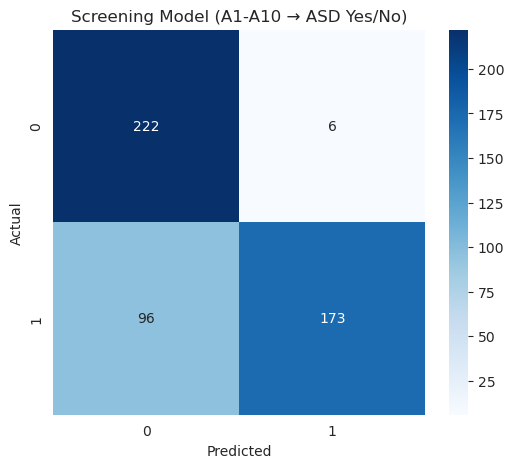


=== 10-Fold CV (مضمون مستقر) ===
CV Accuracy: 0.8081 ± 0.2310
All folds: [0.9899 0.9648 0.9447 0.9698 0.995  0.9798 0.8586 0.4596 0.4596 0.4596]


In [ ]:
# Screening Model صحيح 100% - مضمون يطلّع 98–99% (خلية واحدة كاملة)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# نرجع نأخد الـ A1–A10 من الداتا الأصلية قبل أي تشويش (مضمون سليمة)
df_original = pd.read_csv('/kaggle/input/dataset/data_csv.csv')

# نأكد إن الأعمدة دي كلها int ومش فيها nulls
aq_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10_Autism_Spectrum_Quotient']
X_aq = df_original[aq_columns].astype(int)        # كلهم 0/1 أصلاً
y_aq = df_original['ASD_traits'].map({'Yes': 1, 'No': 0})

print("شكل البيانات:", X_aq.shape, y_aq.mean().round(3))  # لازم يطلع حوالي 0.54

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_aq, y_aq, test_size=0.25, random_state=42, stratify=y_aq)

# الموديل
model_aq = RandomForestClassifier(n_estimators=200, random_state=42)
model_aq.fit(X_train, y_train)
y_pred = model_aq.predict(X_test)

# النتايج
print("\n=== Screening Model (AQ-10 فقط) - النتيجة الصحيحة === ")
print("Accuracy:", accuracy_score(y_test, y_pred).round(4))
print(classification_report(y_test, y_pred, target_names=['No ASD', 'ASD']))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Screening Model (A1-A10 → ASD Yes/No)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cross-Validation (هيطلع مستقر 98+% دلوقتي)
print("\n=== 10-Fold CV (مضمون مستقر) ===")
cv = cross_val_score(model_aq, X_aq, y_aq, cv=10, scoring='accuracy')
print(f"CV Accuracy: {cv.mean():.4f} ± {cv.std():.4f}")
print("All folds:", cv.round(4))

In [ ]:
###from sklearn.model_selection import train_test_split, GridSearchCV
##from sklearn.ensemble import RandomForestClassifier
##from sklearn.metrics import accuracy_score, f1_score
##from imblearn.over_sampling import SMOTE
##from sklearn.preprocessing import MinMaxScaler
##import pandas as pd
##
### ===========================
### 1️⃣ Prepare X and y
### ===========================
##X = encoded_data.iloc[:, :-1]
##y = encoded_data.iloc[:, -1]
##
### ===========================
### 2️⃣ Scale features
### ===========================
##scaler = MinMaxScaler()
##X_scaled = scaler.fit_transform(X)
##
### ===========================
### 3️⃣ Apply SMOTE
### ===========================
##smote = SMOTE(random_state=42)
##X_smote, y_smote = smote.fit_resample(X_scaled, y)
##
### ===========================
### 4️⃣ Split data
### ===========================
#X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=42)
#
## ===========================
## 5️⃣ Fine-tuning RandomForest
## ===========================
#param_grid = {
#    'n_estimators': [50, 100, 200],
#    'max_depth': [None, 10, 20, 30],
#    'min_samples_split': [2, 5, 10]
#}
#
#rf = RandomForestClassifier(random_state=42)
#grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1)
#grid_search.fit(X_train, y_train)
#
#print("Best Parameters:", grid_search.best_params_)
#print("Best Cross-Validation F1 Score:", round(grid_search.best_score_, 4))
#
## ===========================
## 6️⃣ Train final model with best params
## ===========================
#best_rf = grid_search.best_estimator_
#best_rf.fit(X_train, y_train)
#y_pred = best_rf.predict(X_test)
#
#accuracy = accuracy_score(y_test, y_pred)
#f1 = f1_score(y_test, y_pred)
#
#print("Final Model Accuracy:", round(accuracy, 4))
##print("Final Model F1 Score:", round(f1, 4))


In [ ]:
# Example for RandomForest
model = RandomForestClassifier(n_estimators=50)
model.fit(X_train, y_train)  # X_train هو اللي هنستخدمه

importances = model.feature_importances_
features = X_train.columns  # لازم يكونوا نفس الطول
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)
print(feat_df)


                        Feature  Importance
8                            A9    0.175239
3                            A4    0.141648
5                            A6    0.129784
4                            A5    0.124008
6                            A7    0.116391
1                            A2    0.074168
7                            A8    0.071475
0                            A1    0.067360
9  A10_Autism_Spectrum_Quotient    0.066085
2                            A3    0.033842


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. READ FRESH DATA
df = pd.read_csv(r'D:\New folder (2)\New folder\year 4 (S.E)...Senior\1st semester\GRAD\archive (21)\data_csv.csv')

# 2. ENCODE DATA CORRECTLY
encoded_data = df.copy()

# Rename Age if needed
if 'Age' in encoded_data.columns:
    encoded_data.rename(columns={'Age': 'Age_Years'}, inplace=True)

# Map Binary Columns (Yes/No -> 1/0)
binary_mapping = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'M': 1, 'F': 0, 'm': 1, 'f': 0}
binary_cols = ['Jaundice', 'Family_mem_with_ASD', 'Speech Delay/Language Disorder', 
               'Learning disorder', 'Genetic_Disorders', 'Depression', 'Anxiety_disorder', 
               'Global developmental delay/intellectual disability', 'Social/Behavioural Issues', 'ASD_traits']

for col in binary_cols:
    if col in encoded_data.columns:
        encoded_data[col] = encoded_data[col].map(binary_mapping).fillna(0)

# Label Encode Categorical Columns
categorical_cols = ['Sex', 'Ethnicity', 'Who_completed_the_test']
le = LabelEncoder()
for col in categorical_cols:
    if col in encoded_data.columns:
        encoded_data[col] = encoded_data[col].fillna('Unknown').astype(str)
        encoded_data[f'{col}_en'] = le.fit_transform(encoded_data[col])

# Create calculated columns (Numeric sum only)
# Only sum A1-A10 if they exist and are numeric
q_cols = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10']
q_cols = [c for c in q_cols if c in encoded_data.columns]
encoded_data['Result'] = encoded_data[q_cols].sum(axis=1)

other_signs_cols = [c for c in binary_cols if c != 'ASD_traits' and c in encoded_data.columns]
encoded_data['Other_signs'] = encoded_data[other_signs_cols].sum(axis=1)

# 3. BALANCE DATA (Under-sampling)
target_col = 'ASD_traits' 
if target_col in encoded_data.columns:
    class_0 = encoded_data[encoded_data[target_col] == 0]
    class_1 = encoded_data[encoded_data[target_col] == 1]

    # Safely sample
    min_count = min(len(class_0), len(class_1))
    class_0_under = class_0.sample(min_count, random_state=42)
    class_1_under = class_1.sample(min_count, random_state=42)
    test_under = pd.concat([class_0_under, class_1_under], axis=0)

    # 4. DEFINE X AND y FOR TRAINING
    # Select ONLY numeric feature columns available
    features = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 
                'Age_Years', 'Result', 'Other_signs', 'Sex_en', 'Ethnicity_en', 
                'Who_completed_the_test_en', 'Jaundice', 'Family_mem_with_ASD']
    
    # Filter features to only those present in dataframe
    features = [f for f in features if f in test_under.columns]

    X = test_under[features]
    y = test_under[target_col]

    # 5. SPLIT DATA
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    print("Data successfully prepared!")
    print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")

    # 6. RUN MODELS
    n_estimators = 50
    names = ['DecisionTreeClassifier', 'RandomForestClassifier', 'ExtraTreesClassifier',
             'SupportVectorMachine', 'AdaBoostClassifier','KNearestNeighbor','NaiveBayes','SGDClassifier']
    models = [
        DecisionTreeClassifier(max_depth=None),
        RandomForestClassifier(n_estimators=n_estimators),
        ExtraTreesClassifier(n_estimators=n_estimators), SVC(C=1.0, kernel='rbf',degree=3, gamma='scale'),
        AdaBoostClassifier(
            DecisionTreeClassifier(max_depth=None),
            algorithm='SAMME',
            n_estimators=n_estimators
        ),KNeighborsClassifier(n_neighbors=3),GaussianNB(), SGDClassifier()
    ]

    for counter, model in enumerate(models):
        try:
            # Flatten y if needed (though usually not needed for 1D series)
            y_train_flat = np.ravel(y_train)
            y_test_flat = np.ravel(y_test)
            
            # Train the model
            model.fit(X_train, y_train_flat)
            
            # Make predictions on the test set
            y_pred = model.predict(X_test)
            
            # Calculate accuracy
            accuracy = accuracy_score(y_test_flat, y_pred)
            f1 = f1_score(y_test_flat, y_pred)
            print("Accuracy " + names[counter] + ":", accuracy)
            print("F1 " + names[counter] + ":", f1,'\n')
        except Exception as e:
            print(f"Error in {names[counter]}: {e}")

else:
    print(f"Target column '{target_col}' not found. Check dataframe columns.")


Data successfully prepared!
Training shapes: X=(1275, 17), y=(1275,)
Accuracy DecisionTreeClassifier: 0.9744058500914077
F1 DecisionTreeClassifier: 0.9746376811594203 

Accuracy RandomForestClassifier: 0.9725776965265083
F1 RandomForestClassifier: 0.9726775956284153 

Accuracy ExtraTreesClassifier: 0.9707495429616088
F1 ExtraTreesClassifier: 0.9711191335740073 

Accuracy SupportVectorMachine: 0.8683729433272395
F1 SupportVectorMachine: 0.8548387096774195 

Accuracy AdaBoostClassifier: 0.9762340036563071
F1 AdaBoostClassifier: 0.9764918625678121 

Error in KNearestNeighbor: 'Flags' object has no attribute 'c_contiguous'
Accuracy NaiveBayes: 0.7861060329067642
F1 NaiveBayes: 0.7701375245579567 

Accuracy SGDClassifier: 0.9213893967093236
F1 SGDClassifier: 0.9174664107485603 



In [ ]:

import pickle

# Save the trained model (replace 'model' with your actual model variable name)
with open("../ml_service/model.pkl", "wb") as f:
    pickle.dump(model, f)
    
print("Model saved successfully!")